# GGMM + BIC: 새 적합과 실측 시간

이 노트북 하나로 실행합니다. **준비 → 표본 준비 → 새 적합** 순서로 실행한 뒤,
실험 1~9 중 원하는 셀을 실행하세요. 각 실험의 표와 그림은 같은 셀에서 나옵니다.

- 적합 셀의 `K_MAX=10`을 `20`으로 바꾸고 그 셀을 다시 실행하면 같은 X를 새로 적합합니다.
- GGMM 전체 적합·K별·초기값별 시간은 실제 실행에서 측정합니다. 평가·그림 시간은 제외합니다.
- 모든 실험 함수는 현재 `result`를 직접 받습니다. 앞의 다른 실험 셀을 실행할 필요가 없습니다.
- 성공한 실행은 현재 커널의 `runs`에 보관됩니다. 이전 것을 쓰려면 `result = runs[원하는_run_id]`로 선택합니다.
- 새 적합이 실패하면 `result=None`으로 남습니다. 기존 실행은 `runs`에 유지됩니다.
- PKL, 내장된 과거 적합값, 해시 비교, 자동 결과 저장을 사용하지 않습니다.
- 커널을 다시 시작하면 메모리의 result/runs는 사라집니다. 필요할 때 사용자가 결과를 저장하세요.
- 선택 실험 10·11은 기본적으로 꺼져 있습니다. 켜면 조건별 전체 GGMM 적합을 다시 수행합니다.
- 저장된 표·그림은 로컬 검증 실행의 출력입니다. 새 적합 후 원하는 실험 셀을 다시 실행하세요.

참 밀도는 생성·사후 평가에만 사용합니다. GGMM의 fit 입력은 X 하나입니다.
실제 자료를 사용하면 `truth=None`으로 설정하며 IAE·ISE는 계산하지 않습니다.
K_max는 후보 탐색의 상한입니다. BIC는 계산된 국소 적합들 가운데 선택하며 참 K를 보장하지 않습니다.
VGM의 최대 성분 수는 `VGM_MAX_COMPONENTS`로 별도 지정합니다.
필요 패키지: NumPy, SciPy, pandas, Matplotlib, scikit-learn, threadpoolctl, IPython.


In [1]:
# 준비: GGMM 추정기와 비교 함수 정의
# 결과를 불러오거나 적합하지 않습니다. 이 셀을 다시 실행해도 result를 덮어쓰지 않습니다.
"""Independent GGMM estimator with BIC-based component-count selection.

No CDF objective, DKW selection, shape penalty, b upper bound, random
initialization, held-out sample, or fitted GMM input. This is numerical local
maximum likelihood, not a variational Bayesian GGMM or guaranteed global MLE.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
from typing import cast
import numpy as np
from numpy.typing import ArrayLike
from scipy.optimize import minimize, brentq
from scipy.special import gammaln, digamma, logsumexp
from scipy.stats import gennorm


@dataclass(frozen=True)
class GGMMBICConfig:
    max_components: int = 10
    scale_floor_relative: float = 1e-3  # a_min / sample population SD
    max_iter: int = 1500
    ftol: float = 1e-10
    gtol: float = 1e-5


@dataclass(init=False)
class Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __init__(self, weights: ArrayLike, means: ArrayLike, scales: ArrayLike, shapes: ArrayLike):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.scales = np.asarray(scales, dtype=float)
        self.shapes = np.asarray(shapes, dtype=float)
        self.__post_init__()

    def __post_init__(self):
        for name in ('weights', 'means', 'scales', 'shapes'):
            setattr(self, name, np.asarray(getattr(self, name), float))
        if (self.weights.ndim != 1 or len(self.weights) == 0
                or any(getattr(self, p).shape != self.weights.shape
                       for p in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, p)).all()
                           for p in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights <= 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        q = 1 / self.shapes
        with np.errstate(over='ignore'):
            return np.exp(np.log(self.scales) + .5 * (
                gammaln(1 + 3*q) - gammaln(1 + q) - np.log(3.)))

    def component_logpdf(self, x):
        return component_terms(np.asarray(x).reshape(-1), self.means,
                               np.log(self.scales), np.log(self.shapes))[0]

    def logpdf(self, x):
        return cast(np.ndarray, logsumexp(self.component_logpdf(x) + np.log(self.weights), axis=1))

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        # The power may overflow in distant tails; the limiting CDF is 0 or 1.
        with np.errstate(over='ignore'):
            return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                                loc=self.means, scale=self.scales) * self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels],
                           scale=self.scales[labels])

    def payload(self):
        return {p: getattr(self, p).tolist() for p in ('weights','means','scales','shapes')}

    def formula(self, digits=6):
        """g(x;mu,a,b) parameterization; rounded for display only."""
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
                         for w,m,a,b in zip(self.weights,self.means,self.scales,self.shapes))


def unpack(theta, k):
    logits = np.r_[theta[:k-1], 0.]
    lw = logits - cast(float, logsumexp(logits))
    return lw, theta[k-1:2*k-1], theta[2*k-1:3*k-1], theta[3*k-1:]


def pack(model):
    return np.r_[np.log(model.weights[:-1]/model.weights[-1]), model.means,
                 np.log(model.scales), np.log(model.shapes)]


def component_terms(x, mu, la, eta):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        b, q = np.exp(eta), np.exp(-eta)
        if np.any(b == 0) or np.any(q == 0):
            raise FloatingPointError('Shape cannot be represented.')
        norm = -np.log(2.) - la - gammaln(1 + q)
        dc = q * digamma(1 + q)
    if not np.isfinite(norm).all() or not np.isfinite(dc).all():
        raise FloatingPointError('Shape normalizer cannot be represented.')
    delta = x[:, None] - mu
    with np.errstate(divide='ignore', over='ignore', invalid='ignore', under='ignore'):
        lr = np.log(np.abs(delta)) - la
        lt = b * lr
        lp = norm - np.exp(lt)
    if np.isnan(lp).any():
        raise FloatingPointError('Invalid component density.')
    return lp, delta, lr, lt, dc


def nll_gradient(theta, x, k):
    """Mean NLL and exact derivatives where location derivatives exist.

    For b<=1, x=mu is nonsmooth; a zero location subgradient/convention is
    used at exact equality and this event is reported. No exponent clipping.
    """
    lw, mu, la, eta = unpack(theta, k)
    lp, delta, lr, lt, dc = component_terms(x, mu, la, eta)
    joint = lp + lw
    denom = cast(np.ndarray, logsumexp(joint, axis=1))
    if not np.isfinite(denom).all():
        raise FloatingPointError('Nonfinite mixture log density at an observation.')
    log_r = joint - denom[:, None]
    r = np.exp(log_r)
    with np.errstate(over='raise', invalid='raise', divide='ignore', under='ignore'):
        valid = np.isfinite(joint) & np.isfinite(lt)
        log_rbt = np.full_like(log_r, -np.inf)
        np.add(log_r + eta, lt, out=log_rbt, where=valid)
        rbt = np.exp(log_rbt)
        log_location = np.full_like(log_rbt, -np.inf)
        np.subtract(log_rbt, np.log(np.abs(delta)), out=log_location, where=delta != 0)
        location = np.sign(delta)*np.exp(log_location)
        shape_term = np.zeros_like(rbt)
        np.multiply(rbt, lr, out=shape_term, where=rbt != 0)
        grad = np.r_[np.exp(lw[:-1])-r.mean(axis=0)[:-1], -location.mean(axis=0),
                     (r-rbt).mean(axis=0), (shape_term-r*dc).mean(axis=0)]
    if not np.isfinite(grad).all():
        raise FloatingPointError('Nonfinite likelihood derivative.')
    return float(-denom.mean()), grad


def initial_shape(group):
    """Match mean absolute deviation / SD; fallback only if moment equation fails.

    The theoretical ratio increases from 0 to sqrt(3)/2. A finite sample's
    moment ratio can lie outside that interval. The b=2 fallback is a starting
    point, not a shape restriction or representative-shape assertion.
    """
    mu, sd = float(np.mean(group)), float(np.std(group))
    ratio = float(np.mean(np.abs(group-mu))/sd) if sd > 0 else np.nan
    if len(group) < 4 or not 0 < ratio < np.sqrt(3)/2:
        return 2., True
    def residual(eta):
        q = np.exp(-eta)
        return .5*np.log(3)-np.log(2)+gammaln(1+2*q)-.5*(
            gammaln(1+q)+gammaln(1+3*q))-np.log(ratio)
    lo, hi = -1., 1.
    while residual(lo) > 0 and lo > -16:
        lo -= 1
    while residual(hi) < 0 and hi < 24:
        hi += 1
    if residual(lo) * residual(hi) > 0:
        return 2., True
    return float(np.exp(cast(float, brentq(residual, lo, hi)))), False


def initializations(x, k, floor):
    """Two deterministic partitions, no density model fitted during initialization."""
    quantile = np.minimum(np.arange(len(x))*k//len(x), k-1)
    centers = np.quantile(x, (np.arange(k)+.5)/k)
    labels = None
    for _ in range(100):
        distance = (x[:, None]-centers)**2
        new = distance.argmin(axis=1)
        counts = np.bincount(new, minlength=k)
        for j in np.flatnonzero(counts == 0):
            residual = distance[np.arange(len(x)), new].copy()
            residual[counts[new] <= 1] = -np.inf
            i = int(np.argmax(residual))
            counts[new[i]] -= 1
            new[i] = j
            counts[j] += 1
        if labels is not None and np.array_equal(new, labels):
            break
        labels = new
        centers = np.array([x[labels == j].mean() for j in range(k)])
    assert labels is not None
    partitions = [('quantile', quantile)]
    if not np.array_equal(labels, quantile):
        partitions.append(('lloyd', labels))
    for name, groups in partitions:
        parts = [x[groups == j] for j in range(k)]
        bs = [initial_shape(p) for p in parts]
        b = np.array([t[0] for t in bs])
        sigma = np.array([max(p.std(), floor) for p in parts])
        la = np.log(sigma) + .5*(np.log(3)+gammaln(1+1/b)-gammaln(1+3/b))
        a = np.exp(np.maximum(la, np.log(floor)))
        yield name, Mixture(np.array([len(p) for p in parts])/len(x),
                            np.array([p.mean() for p in parts]), a, b), sum(t[1] for t in bs)


class GGMMBICEstimator:
    def __init__(self, config=None):
        self.config = config or GGMMBICConfig()

    def fit(self, X):
        # Reusing this estimator must never expose a previous selected density
        # after an invalid or interrupted fit.
        self.__dict__ = {'config': self.config, 'fit_status_': 'running'}
        cfg = self.config
        x = np.asarray(X, float)
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim != 1 or len(x) < 4 or not np.isfinite(x).all():
            raise ValueError('Provide one finite continuous sample, with at least four observations.')
        if (not isinstance(cfg.max_components, int) or cfg.max_components < 1
                or not np.isfinite(cfg.scale_floor_relative) or cfg.scale_floor_relative <= 0
                or cfg.max_iter < 1 or not 0 < cfg.ftol < 1 or not 0 < cfg.gtol < 1):
            raise ValueError('Invalid configuration.')
        start = perf_counter()
        self.center_, self.unit_ = float(np.mean(x)), float(np.std(x))
        if not np.isfinite(self.unit_) or self.unit_ <= 0:
            raise ValueError('Constant or unrepresentable range: use a separate constant-column handler.')
        z = np.sort((x-self.center_)/self.unit_)
        if not np.isfinite(z).all():
            raise ValueError('Rescale the observations before fitting.')
        self.a_min_ = cfg.scale_floor_relative*self.unit_
        self.starts_, self.selection_, self.models_ = [], [], {}
        upper = min(cfg.max_components, len(np.unique(z)), len(z))
        previous_ll = -np.inf
        for k in range(1, upper+1):
            tick = perf_counter()
            bounds = [(None, None)]*(2*k-1) + [(np.log(cfg.scale_floor_relative), None)]*k + [(None, None)]*k
            candidates = []
            init_tick = perf_counter()
            starts = list(initializations(z, k, cfg.scale_floor_relative))
            initialization_seconds = perf_counter()-init_tick
            for name, initial, fallback_count in starts:
                start_tick = perf_counter()
                best = [np.inf, None]
                rejected = [0]
                def objective(theta):
                    try:
                        value, grad = nll_gradient(theta, z, k)
                        if value < best[0]:
                            best[:] = value, theta.copy()
                        return value, grad
                    except (FloatingPointError, ValueError):
                        rejected[0] += 1
                        return np.inf, np.zeros_like(theta)
                theta0 = pack(initial)
                objective(theta0)
                optimize_tick = perf_counter()
                opt = minimize(objective, theta0, jac=True, method='L-BFGS-B', bounds=bounds,
                               options=dict(maxiter=cfg.max_iter, ftol=cfg.ftol, gtol=cfg.gtol, maxls=50))
                optimize_seconds = perf_counter()-optimize_tick
                timing = dict(optimization_seconds=optimize_seconds,
                              nfev=int(getattr(opt, 'nfev', -1)))
                theta = best[1]
                if theta is None:
                    self.starts_.append(dict(K=k, start=name, finite=False, converged=False,
                        message='No finite likelihood', rejected_steps=rejected[0],
                        seconds=perf_counter()-start_tick, **timing))
                    continue
                value, grad = nll_gradient(theta, z, k)
                # Returning the best visited point avoids discarding a better finite trial.
                # If it differs from the optimizer endpoint, do not claim convergence.
                at_endpoint = bool(np.allclose(theta, opt.x, rtol=1e-10, atol=1e-10))
                for j in range(2*k-1, 3*k-1):
                    if theta[j] <= np.log(cfg.scale_floor_relative)+1e-8 and grad[j] > 0:
                        grad[j] = 0
                lw, mu, la, eta = unpack(theta, k)
                order = np.argsort(mu)
                try:
                    model = Mixture(np.exp(lw)[order], (self.center_+self.unit_*mu)[order],
                                    (self.unit_*np.exp(la))[order], np.exp(eta)[order])
                except ValueError as exc:
                    self.starts_.append(dict(K=k, start=name, finite=False, converged=False,
                        message=f'Unrepresentable final mixture: {exc}', rejected_steps=rejected[0],
                        seconds=perf_counter()-start_tick, **timing))
                    continue
                ll = float(-len(z)*(value+np.log(self.unit_)))
                row = dict(K=k, start=name, finite=True, log_likelihood=ll,
                           BIC=-2*ll+(4*k-1)*np.log(len(z)), converged=bool(opt.success and at_endpoint),
                           projected_gradient=float(np.max(np.abs(grad))), iterations=int(opt.nit),
                           message=str(opt.message), best_is_endpoint=at_endpoint,
                           rejected_steps=rejected[0], initial_shapes=initial.shapes.tolist(),
                           moment_fallback_components=int(fallback_count),
                           a_floor_hits=int(np.sum(model.scales <= self.a_min_*(1+1e-6))),
                           max_b=float(model.shapes.max()), min_b=float(model.shapes.min()),
                           nonsmooth_coincidences=int(np.sum((z[:, None] == mu) & (np.exp(eta) <= 1))))
                row.update(seconds=perf_counter()-start_tick, **timing)
                self.starts_.append(row)
                candidates.append((row, model))
            if not candidates:
                self.selection_.append(dict(K=k, finite=False, converged=False, BIC=np.inf,
                    log_likelihood=np.nan, seconds=perf_counter()-tick,
                    initialization_seconds=initialization_seconds, starts_count=len(starts)))
                continue
            row, model = min(candidates, key=lambda item: item[0]['BIC'])
            row = row.copy()
            row.update(seconds=perf_counter()-tick,
                       initialization_seconds=initialization_seconds, starts_count=len(starts),
                       likelihood_decreased=bool(row['log_likelihood'] < previous_ll-1e-5))
            previous_ll = max(previous_ll, row['log_likelihood'])
            self.models_[k] = model
            self.selection_.append(row)
        finite = [r for r in self.selection_ if r['finite']]
        if not finite:
            raise RuntimeError('All fits failed; inspect starts_.')
        winner = min(finite, key=lambda r: r['BIC'])
        self.n_components_ = winner['K']
        self.density_ = self.models_[self.n_components_]
        for r in self.selection_:
            r['delta_BIC'] = r['BIC']-winner['BIC']
            r['selected'] = r['K'] == self.n_components_
        self.diagnostics_ = dict(n=len(x), selected_K=self.n_components_, config=asdict(cfg),
            effective_Kmax=upper,
            scale_floor_original_units=self.a_min_, selected_converged=winner['converged'],
            any_K_nonconverged=any(not r['converged'] for r in self.selection_),
            any_likelihood_decrease=any(r.get('likelihood_decreased',False) for r in self.selection_),
            selected_at_Kmax=self.n_components_ == upper,
            status='numerical_local_fit; no global optimum or true-K guarantee', seconds=perf_counter()-start)
        self.fit_status_ = 'complete'
        return self

    def predict_proba(self, X):
        joint = self.density_.component_logpdf(X) + np.log(self.density_.weights)
        denominator = cast(np.ndarray, logsumexp(joint, axis=1))
        if not np.isfinite(denominator).all():
            raise FloatingPointError('Posterior probabilities cannot be represented for these values.')
        return np.exp(joint-denominator[:, None])


"""Synthetic experiment and comparison for the BIC-selected GGMM estimator.

Truth is passed to generation and POST-FIT evaluation only. All reported
densities are normalized plug-in mixtures, including sklearn's VGM comparator.
"""
from dataclasses import asdict, replace
from datetime import datetime, timezone
from time import perf_counter
from typing import Any, TypedDict, cast
import platform
import warnings
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.special import gammaln
from scipy.stats import gennorm, gaussian_kde
from scipy.integrate import trapezoid, quad_vec
from IPython.display import display
from sklearn.mixture import BayesianGaussianMixture
from threadpoolctl import threadpool_limits


TRUTH_PARAMETERS = dict(weights=[.2,.3,.5], means=[-5.,0.,6.],
                        scales=[1.2,1.6,2.], shapes=[1.5,4.,8.])
SAMPLE_SIZE = 5000
SAMPLE_SEED = 20260912
VGM_SEED = 27


class ExperimentResult(TypedDict):
    run_id: str
    x: np.ndarray
    truth: Mixture | None
    ggmm: GGMMBICEstimator
    config: dict[str, Any]
    fit_seconds: float
    selection: pd.DataFrame
    starts: pd.DataFrame
    parameters: pd.DataFrame
    metadata: dict[str, Any]


def sample_mixture(truth, n, seed) -> np.ndarray:
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return cast(np.ndarray, gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                                       scale=truth.scales[labels], random_state=rng))


def _points(model, tail):
    probabilities = [tail,1e-7,1e-5,.001,.01,.05,.1,.25,.5,.75,.9,.95,.99,.999,1-1e-5,1-1e-7,1-tail]
    p = np.tile(probabilities, model.k)
    labels = np.repeat(np.arange(model.k), len(probabilities))
    return np.unique(np.r_[model.component_ppf(p, labels), model.means,
                           model.means-model.scales, model.means+model.scales])


def density_errors(truth, fitted, tail=1e-9, atol=1e-7, rtol=1e-5):
    """Post-fit IAE/ISE: adaptive 32/64-node panels and omitted-tail bounds.

    Quadrature errors are estimates, not formal interval arithmetic bounds.
    The true density is never used for K selection or any fitting setting.
    """
    points = np.unique(np.r_[_points(truth,tail), _points(fitted,tail)])
    if not np.isfinite(points).all():
        raise FloatingPointError('Evaluation quantiles cannot be represented.')
    left,right = points[:-1],points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels,int)
    total,error = np.zeros(2),np.zeros(2)
    unresolved = 0
    def panel(l,r,order):
        nodes,weights = leggauss(order)
        mid,half = l/2+r/2,(r-l)/2
        xx = mid[:,None]+half[:,None]*nodes
        delta = (fitted.pdf(xx.ravel())-truth.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:,None]
    while len(left):
        low, high = panel(left,right,32), panel(left,right,64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:,None])+rtol*np.abs(high),axis=1)
        stopped = depth >= 12
        accept = good|stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped&~good))
        ll,rr,dd = left[~accept],right[~accept],depth[~accept]
        mid = ll/2+rr/2
        left,right,depth = np.r_[ll,mid],np.r_[mid,rr],np.r_[dd+1,dd+1]
    lo,hi = points[0],points[-1]
    def omitted(model):
        return float(np.clip(model.cdf([lo])[0]+1-model.cdf([hi])[0],0,1))
    def peak(model):
        return float(np.sum(model.weights*np.exp(-np.log(2)-np.log(model.scales)-gammaln(1+1/model.shapes))))
    tt,tf = omitted(truth),omitted(fitted)
    return dict(IAE=float(total[0]), ISE=float(total[1]),
        IAE_quadrature_error=float(error[0]), ISE_quadrature_error=float(error[1]),
        IAE_omitted_tail_upper=tt+tf, ISE_omitted_tail_upper=peak(truth)*tt+peak(fitted)*tf,
        quadrature_tolerance_met=bool(np.all(error <= atol+rtol*np.abs(total))),
        unresolved_panels=unresolved, integration_left=float(lo), integration_right=float(hi))


def fit_vgm(x, max_components=10):
    """RDT-style prior and active threshold; larger convergence budget disclosed."""
    tick = perf_counter()
    fitted = BayesianGaussianMixture(n_components=max_components, covariance_type='full',
        weight_concentration_prior_type='dirichlet_process', weight_concentration_prior=.001,
        init_params='kmeans', n_init=1, max_iter=1500, tol=1e-3, reg_covar=1e-6, random_state=VGM_SEED)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fitted.fit(x.reshape(-1,1))
    seconds = perf_counter()-tick
    w,mu,a = fitted.weights_,fitted.means_[:,0],np.sqrt(2*fitted.covariances_[:,0,0])
    full = Mixture(w/w.sum(),mu,a,np.full(len(w),2.))
    mask = w > .005
    active = Mixture(w[mask]/w[mask].sum(),mu[mask],a[mask],np.full(int(mask.sum()),2.))
    diagnostic = dict(converged=bool(fitted.converged_),iterations=int(fitted.n_iter_),
        seconds=seconds,active_K=int(mask.sum()),max_components=max_components,
        active_threshold=.005,inactive_mass=float(w[~mask].sum()),
        settings=fitted.get_params(), warnings=[str(v.message) for v in caught],
        comparison_note='Raw X; RDT-style DP prior/threshold; max_iter raised from 100 to 1500.')
    return full,active,diagnostic


def parameter_table(model):
    return pd.DataFrame(dict(component=np.arange(1,model.k+1),weight=model.weights,
                             mu=model.means,a=model.scales,b=model.shapes,
                             sigma_derived=model.sigmas))



def run_experiment(x, *, config=None, truth=None, sample_seed=None,
                   vgm_max_components=10, threads=1) -> ExperimentResult:
    """Always fit a new GGMM from one X. No cache, files or truth in fit().

    The returned result owns a copy of X and its configuration. Replacing the
    notebook's result does not mutate earlier results kept by the caller.
    """
    cfg = config or GGMMBICConfig()
    observed = np.array(x, dtype=float, copy=True)
    if observed.ndim == 2 and observed.shape[1] == 1:
        observed = observed[:, 0].copy()
    if observed.ndim != 1:
        raise ValueError('X must be one continuous column.')
    if not isinstance(threads, int) or threads < 1:
        raise ValueError('threads must be a positive integer.')
    if not isinstance(vgm_max_components, int) or vgm_max_components < 1:
        raise ValueError('vgm_max_components must be a positive integer.')
    reference = None if truth is None else Mixture(**truth.payload())
    created = datetime.now(timezone.utc).isoformat(timespec='microseconds')
    fitted = GGMMBICEstimator(cfg)
    with threadpool_limits(limits=threads):
        # Time the complete fit() call, including initialization and K selection.
        # Input copying, generation, evaluation and plotting are outside it.
        tick = perf_counter()
        fitted.fit(observed)
        fit_seconds = perf_counter()-tick
    observed.setflags(write=False)
    return ExperimentResult(
        run_id=created, x=observed, truth=reference, ggmm=fitted,
        config=asdict(cfg), fit_seconds=fit_seconds,
        selection=pd.DataFrame(fitted.selection_),
        starts=pd.DataFrame(fitted.starts_),
        parameters=parameter_table(fitted.density_),
        metadata=dict(sample_seed=sample_seed, sample_size=len(observed), threads=threads,
            vgm_max_components=vgm_max_components, vgm_seed=VGM_SEED,
            versions=dict(python=platform.python_version(), numpy=np.__version__,
                scipy=scipy.__version__, sklearn=sklearn.__version__,
                pandas=pd.__version__, matplotlib=matplotlib.__version__),
            timing='New GGMM fit call; includes all K and BIC; excludes reports and I/O.'))


def require_result(result):
    if not isinstance(result, dict) or not {'x', 'ggmm', 'config', 'fit_seconds'} <= result.keys():
        raise RuntimeError('먼저 GGMM 적합 셀을 성공적으로 실행하세요.')
    if result['ggmm'].fit_status_ != 'complete':
        raise RuntimeError('완료된 GGMM 적합 결과가 아닙니다.')
    return result


def show_table(table):
    with pd.option_context('display.max_columns', None, 'display.max_rows', 100,
                           'display.float_format', '{:.6f}'.format):
        display(table)


def report_context(result):
    require_result(result)
    print(f"Run: {result['run_id']} | n={len(result['x']):,} | "
          f"K_max={result['config']['max_components']} | "
          f"선택 K={result['ggmm'].n_components_}")
    if result['truth'] is None:
        print('참 밀도가 없는 자료: IAE·ISE와 참 밀도 오차 그림은 계산하지 않습니다.')
    return result['x'], result['truth'], result['ggmm']


def plot_grid(result, models, padding: float = 0):
    x = result['x']
    knots = np.unique(np.concatenate([x, *[_points(m, 1e-6) for m in models if m is not None]]))
    lo, hi = min(knots.min(), x.min()-padding), max(knots.max(), x.max()+padding)
    return np.unique(np.r_[np.linspace(lo, hi, 5000), knots])


def show_density_errors(result, grid, curves, title):
    x, truth = result['x'], result['truth']
    fig = plt.figure(figsize=(12, 7 if truth is not None else 4), layout='constrained')
    if truth is not None:
        gs = fig.add_gridspec(2, 2)
        ax = fig.add_subplot(gs[0, :])
        errors = [fig.add_subplot(gs[1, j]) for j in range(2)]
        true_pdf = truth.pdf(grid)
        ax.plot(grid, true_pdf, 'k:', lw=1.8, label='True density')
    else:
        ax, errors, true_pdf = fig.add_subplot(), [], None
    ax.hist(x, bins=85, density=True, color='#dce2e8', edgecolor='white',
            linewidth=.3, label=f'Sample (n={len(x):,})')
    for label, pdf, color, style in curves:
        ax.plot(grid, pdf, color=color, ls=style, lw=2, label=label)
        if true_pdf is not None:
            delta = pdf-true_pdf
            errors[0].plot(grid, np.abs(delta), color=color, ls=style)
            errors[1].plot(grid, delta**2, color=color, ls=style)
    ax.set(title=title, ylabel='Density')
    ax.legend(ncol=2, fontsize=9, frameon=False)
    for panel, name in zip(errors, ['Absolute error', 'Squared error']):
        panel.set(title=name, ylabel=name)
    for panel in [ax, *errors]:
        panel.set(xlabel='x', xlim=(grid[0], grid[-1]), ylim=(0, None))
        panel.spines[['top', 'right']].set_visible(False)
    plt.show()


def mixture_row(result, name, model, seconds, converged) -> dict[str, Any]:
    tick = perf_counter()
    with threadpool_limits(limits=result['metadata']['threads']):
        ll = float(model.logpdf(result['x']).sum())
        errors = (density_errors(result['truth'], model) if result['truth'] is not None
                  else dict(IAE=np.nan, ISE=np.nan, quadrature_tolerance_met=None))
    return dict(Method=name, K=model.k, LL=ll, IAE=errors['IAE'], ISE=errors['ISE'],
        Fit_s=seconds, Evaluation_s=perf_counter()-tick, Converged=converged,
        Integral_OK=errors['quadrature_tolerance_met'])


def compare_vgm(result, cap):
    # Refit on this run's X. No global VGM is inherited from another report.
    with threadpool_limits(limits=result['metadata']['threads']):
        return fit_vgm(result['x'], max_components=min(cap, len(result['x'])))


def make_kde(result, subset=False) -> tuple[gaussian_kde, dict[str, Any]]:
    x = result['x']
    indices = (np.random.default_rng(20260914).choice(len(x), 3, replace=False)
               if subset else np.arange(len(x)))
    if np.std(x[indices]) <= 0:
        raise ValueError('선택된 KDE 관측값이 모두 같습니다. 다른 표본에서는 다시 확인해야 합니다.')
    with threadpool_limits(limits=result['metadata']['threads']):
        tick = perf_counter()
        model = gaussian_kde(x[indices], bw_method='scott')
        fit_s = perf_counter()-tick
        tick = perf_counter()
        ll = float(model.logpdf(x).sum())
        ll_s = perf_counter()-tick
    return model, dict(indices=indices, fit_s=fit_s, ll_s=ll_s, ll=ll,
                      h=float(np.sqrt(model.covariance[0, 0])))


def adaptive_kde_error(result, kde):
    x, truth = result['x'], result['truth']
    if truth is None:
        return dict(IAE=np.nan, ISE=np.nan, Integral_OK=None)
    h = float(np.sqrt(kde.covariance[0, 0]))
    points = np.unique(np.r_[_points(truth, 1e-9), np.quantile(x, np.linspace(0, 1, 21)),
                             x.min()-8*h, x.max()+8*h])
    def integrand(t):
        delta = float(kde([t])[0]-truth.pdf([t])[0])
        return np.array([abs(delta), delta**2])
    with threadpool_limits(limits=result['metadata']['threads']):
        values, error, info = quad_vec(integrand, points[0], points[-1],
            points=points[1:-1], epsabs=1e-8, epsrel=0, norm='max', full_output=True)
    return dict(IAE=float(values[0]), ISE=float(values[1]),
                Integral_OK=bool(info.success and error <= 1e-8))


def report_overview(result):
    x, truth, fit = report_context(result)
    selected = fit.density_
    cap = result['metadata']['vgm_max_components']
    _, active, info = compare_vgm(result, cap)
    print('g(x; mu,a,b) = b / [2a Gamma(1/b)] * exp(-|(x-mu)/a|^b)')
    if truth is not None:
        print('참 분포:', truth.formula())
    print('추정 GGMM:', selected.formula())
    show_table(parameter_table(selected)[['component', 'weight', 'mu', 'a', 'b']])
    table = pd.DataFrame([
        mixture_row(result, 'GGMM + BIC', selected, result['fit_seconds'],
                    fit.diagnostics_['selected_converged']),
        mixture_row(result, 'VGM active', active, info['seconds'], info['converged'])])
    show_table(table)
    print(f"VGM: 최대 {info['max_components']}성분, weight>0.005, 실제 유효 K={active.k}.")
    print('Fit_s: GGMM은 이 result를 만든 전체 탐색 시간, VGM은 이 셀의 새 적합 시간.')
    print('평가·그림 시간은 적합시간에 포함하지 않습니다. LL↑, IAE·ISE↓.')
    grid = plot_grid(result, [truth, selected, active])
    show_density_errors(result, grid, [
        (f'GGMM K={selected.k}', selected.pdf(grid), '#c43c39', '-'),
        (f'VGM active K={active.k}', active.pdf(grid), '#2865b0', '--')], 'Selected GGMM and VGM')
    return table


def report_initialization(result):
    _, _, fit = report_context(result)
    records = {r['K']: r for r in fit.selection_}
    rows = []
    for k, rec in sorted(records.items()):
        starts = {r['start']: r for r in fit.starts_ if r['K'] == k}
        row = dict(K=k, Chosen_start=rec.get('start', 'none'))
        for method in ['quantile', 'lloyd']:
            start = starts.get(method, {})
            row[method+'_LL'] = start.get('log_likelihood', np.nan)
            row[method+'_status'] = ('converged' if start.get('converged') else
                                     'not converged' if start else 'duplicate / omitted')
        rows.append(row)
    table = pd.DataFrame(rows)
    show_table(table)
    show_table(pd.DataFrame([dict(Start=r['start'],
        Initial_b=np.round(r.get('initial_shapes', []), 5).tolist(),
        Chosen=r['start'] == records[fit.n_components_].get('start'),
        Optimize_s=r['optimization_seconds'], Start_s=r['seconds'],
        Iterations=r.get('iterations'), Nfev=r['nfev'])
        for r in fit.starts_ if r['K'] == fit.n_components_]))
    print('Initial_b는 최종 추정값이 아닌 출발점입니다. 미수렴·중복 생략을 함께 표시합니다.')
    fig, ax = plt.subplots(figsize=(10, 3.5), layout='constrained')
    for method in ['quantile', 'lloyd']:
        ax.plot(table['K'], table[method+'_LL'], 'o-', label=method)
    ax.set(xlabel='K', ylabel='Log likelihood after fitting', xticks=table['K'])
    ax.legend(frameon=False)
    plt.show()
    return table


def report_selection(result):
    _, _, fit = report_context(result)
    scores = pd.DataFrame(fit.selection_).sort_values('K').copy()
    scores['AIC'] = -2*scores['log_likelihood']+2*(4*scores['K']-1)
    scores['LL_gain'] = scores['log_likelihood'].diff()
    scores['delta_AIC'] = scores['AIC']-scores['AIC'].min()
    show_table(scores.reindex(columns=['K', 'log_likelihood', 'LL_gain', 'AIC', 'BIC',
        'selected', 'converged', 'max_b', 'a_floor_hits', 'seconds']))
    print('계산된 유한 후보의 선택:', {'LL 최대': int(scores.loc[scores.log_likelihood.idxmax(), 'K']),
        'AIC 최소': int(scores.loc[scores.AIC.idxmin(), 'K']), 'BIC 최소': fit.n_components_})
    print('미수렴 후보를 숨기지 않습니다. 현재 선택은 전역 최적해나 참 K 복원을 보장하지 않습니다.')
    boundary = search_boundary(fit.selection_)
    print('탐색 상한 진단:', boundary)
    if boundary['review_larger_K']:
        print('상한을 넓혀 재적합할 필요가 있습니다. 현재 추정기는 자동으로 상한을 늘리지 않습니다.')
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout='constrained')
    for ax, metric in zip(axes, ['log_likelihood', 'delta_AIC', 'delta_BIC']):
        ax.plot(scores.K, scores[metric], 'o-', label='Computed fit')
        bad = scores.loc[~scores.converged]
        ax.scatter(bad.K, bad[metric], marker='x', color='red', label='Not converged')
        ax.set(xlabel='K', ylabel=metric, xticks=scores.K)
        ax.legend(fontsize=8, frameon=False)
    plt.show()
    return scores


def search_boundary(selection):
    """Diagnostic only, not a guarantee that no better larger K exists."""
    rows = sorted(selection, key=lambda r: r['K'])
    finite = [r for r in rows if r['finite']]
    best = min(finite, key=lambda r: r['BIC'])
    last = rows[-1]
    # Check adjacent actual candidates, without jumping over a failed fit.
    tail = rows[-3:]
    descending = len(tail) >= 2 and all(r['finite'] for r in tail) and all(
        b['BIC'] < a['BIC'] for a, b in zip(tail, tail[1:]))
    at_boundary = best['K'] == last['K']
    return dict(effective_Kmax=last['K'], selected_at_boundary=at_boundary,
                last_candidates_BIC_decreasing=descending,
                boundary_not_converged=not last['converged'],
                review_larger_K=bool(at_boundary or descending))


def report_timing(result):
    _, _, fit = report_context(result)
    table = pd.DataFrame(fit.selection_).reindex(columns=['K', 'seconds', 'initialization_seconds',
        'starts_count', 'converged']).rename(columns={'seconds': 'Candidate_s'})
    table['Cumulative_candidate_s'] = table.Candidate_s.cumsum()
    starts = pd.DataFrame(fit.starts_)
    show_table(table)
    show_table(starts.reindex(columns=['K', 'start', 'seconds', 'optimization_seconds',
                                       'iterations', 'nfev', 'converged']))
    print(f"전체 GGMM fit() 실측: {result['fit_seconds']:.6f}초")
    print('Candidate_s는 해당 K의 모든 시작점·초기화·후처리를 포함합니다.')
    print('초기화는 K별로 공동 측정합니다. starts.seconds는 초기화 이후 시도 전체입니다.')
    print('누적 후보 시간은 현재 실행의 부분합이며, 다른 K_max 독립 실행의 실측값은 아닙니다.')
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout='constrained')
    axes[0].bar(table.K, table.Candidate_s, label='All starts + initialization')
    axes[0].bar(table.K, table.initialization_seconds, label='Initialization')
    axes[0].set(xlabel='K', ylabel='Seconds', xticks=table.K, title='Time per candidate')
    axes[0].legend(fontsize=8)
    axes[1].plot(table.K, table.Cumulative_candidate_s, 'o-')
    axes[1].set(xlabel='K', ylabel='Seconds', xticks=table.K, title='Cumulative candidate time')
    plt.show()
    return table


def report_kde(result):
    x, truth, fit = report_context(result)
    selected = fit.density_
    full, full_info = make_kde(result)
    try:
        three, three_info = make_kde(result, subset=True)
    except ValueError as exc:
        print('3개 관측값 KDE를 계산할 수 없습니다:', exc)
        return pd.DataFrame()
    margin = 5*max(full_info['h'], three_info['h'])
    grid = np.linspace(x.min()-margin, x.max()+margin, 4000)
    with threadpool_limits(limits=result['metadata']['threads']):
        curves = [(f'GGMM K={selected.k}', selected.pdf(grid), '#c43c39', '-'),
                  (f'Gaussian KDE n={len(x):,}', full(grid), '#26836b', '--'),
                  ('Gaussian KDE n=3', three(grid), '#365ab0', '-.')]
    specs = [(len(x), selected.k, np.nan, np.nan, result['fit_seconds'], np.nan,
              float(selected.logpdf(x).sum())),
             (len(x), full.n, float(cast(float, full.factor)), full_info['h'], full_info['fit_s'], full_info['ll_s'], full_info['ll']),
             (3, 3, float(cast(float, three.factor)), three_info['h'], three_info['fit_s'], three_info['ll_s'], three_info['ll'])]
    rows = []
    for (name, pdf, _, _), (n, terms, factor, h, fit_s, ll_s, ll) in zip(curves, specs):
        delta = pdf-truth.pdf(grid) if truth is not None else np.full_like(grid, np.nan)
        rows.append(dict(Method=name, Fit_n=n, Terms=terms, Factor=factor, h=h,
            LL_on_all_X=ll, IAE=float(trapezoid(abs(delta), grid)),
            ISE=float(trapezoid(delta**2, grid)), Fit_s=fit_s, LL_s=ll_s))
    table = pd.DataFrame(rows)
    show_table(table)
    print('3-kernel 추출 시드: 20260914 | 인덱스:', three_info['indices'].tolist())
    print('추출 관측값:', np.round(x[three_info['indices']], 6).tolist())
    print('세 모형의 LL은 전체 X에서 평가합니다. 대역폭: Scott. IAE·ISE: 4,000점 사다리꼴 근사.')
    visible = (grid >= min(x.min()-3*full_info['h'], x[three_info['indices']].min()-3*three_info['h'])) & (
               grid <= max(x.max()+3*full_info['h'], x[three_info['indices']].max()+3*three_info['h']))
    show_density_errors(result, grid[visible], [(n, p[visible], c, s) for n, p, c, s in curves],
                        'GGMM and Gaussian KDE')
    return table


def report_same_k(result):
    _, truth, fit = report_context(result)
    records = {r['K']: r for r in fit.selection_}
    rows, matches = [], []
    # Match GGMM to the observed active VGM K, never force VGM to a desired K.
    for cap in dict.fromkeys([3, result['metadata']['vgm_max_components']]):
        _, active, info = compare_vgm(result, cap)
        k = active.k
        if k not in fit.models_:
            print(f'VGM 상한={cap}, 실제 K={k}: 해당 GGMM 후보가 없어 같은 K 비교를 생략합니다.')
            continue
        gg = fit.models_[k]
        for name, model, seconds, converged in [
            ('GGMM', gg, records[k]['seconds'], records[k]['converged']),
            ('VGM active', active, info['seconds'], info['converged'])]:
            row = mixture_row(result, name, model, seconds, converged)
            row.update(VGM_cap=cap, Parameters=(4*k-1 if name == 'GGMM' else 3*k-1))
            rows.append(row)
        matches.append((cap, k, gg, active))
    table = pd.DataFrame(rows)
    show_table(table)
    print('VGM의 실제 유효 K와 같은 GGMM 후보를 비교합니다. K=3·5를 강제로 만들지 않습니다.')
    print('GGMM은 해당 K의 시간, VGM은 최대 성분 수 전체의 시간으로 비용 범위가 다릅니다.')
    for cap, k, gg, vg in matches:
        grid = plot_grid(result, [truth, gg, vg])
        show_density_errors(result, grid, [(f'GGMM K={k}', gg.pdf(grid), '#c43c39', '-'),
            (f'VGM active K={k}', vg.pdf(grid), '#2865b0', '--')], f'{k} vs {k} components (VGM cap={cap})')
    return table


def report_all_k(result):
    _, truth, fit = report_context(result)
    selected = fit.density_
    records = {r['K']: r for r in fit.selection_}
    full, info = make_kde(result)
    rows = [mixture_row(result, f'GGMM K={k}', model, records[k]['seconds'], records[k]['converged'])
            for k, model in sorted(fit.models_.items())]
    tick = perf_counter()
    err = adaptive_kde_error(result, full)
    rows.append(dict(Method='KDE full sample', K=np.nan, LL=info['ll'], Fit_s=info['fit_s'],
                     Evaluation_s=info['ll_s']+perf_counter()-tick, Converged='Scott rule', **err))
    table = pd.DataFrame(rows)
    show_table(table)
    print('참 밀도를 아는 경우에만 IAE·ISE를 사후 계산합니다. K 선택에는 사용하지 않습니다.')
    print('적분은 넓은 유한 구간의 수치 근사입니다. 실패 후보는 선택·시간 표에서 확인하세요.')
    ks = list(dict.fromkeys([selected.k, *[k for k in (3, 4, 5, 9) if k in fit.models_]]))
    grid = plot_grid(result, [truth, *[fit.models_[k] for k in ks]], padding=4*info['h'])
    with threadpool_limits(limits=result['metadata']['threads']):
        kde_pdf = full(grid)
    for k in ks:
        label = f'GGMM K={k}' + (' [not converged]' if not records[k]['converged'] else '')
        show_density_errors(result, grid, [(label, fit.models_[k].pdf(grid), '#c43c39', '-'),
            ('KDE full sample', kde_pdf, '#26836b', '--')], f'Candidate K={k} and KDE')
    return table


def compare_kmax(result, maxima=(10, 20)):
    """Independent fresh fits; do not relabel a prefix sum as measured runtime."""
    report_context(result)
    runs, rows = [], []
    for cap in maxima:
        print(f'새 적합: K_max={cap}', flush=True)
        run = run_experiment(result['x'], truth=result['truth'],
            config=replace(result['ggmm'].config, max_components=int(cap)),
            sample_seed=result['metadata']['sample_seed'],
            vgm_max_components=result['metadata']['vgm_max_components'],
            threads=result['metadata']['threads'])
        runs.append(run)
        row = mixture_row(run, f'K_max={cap}', run['ggmm'].density_, run['fit_seconds'],
                          run['ggmm'].diagnostics_['selected_converged'])
        row.update(K_max=cap, Run=run['run_id'],
                   BIC=float(run['selection'].loc[run['selection'].selected, 'BIC'].iloc[0]))
        rows.append(row)
    table = pd.DataFrame(rows)
    show_table(table)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
    for ax, metric in zip(axes, ['Fit_s', 'K']):
        ax.plot(table.K_max, table[metric], 'o-')
        ax.set(xlabel='Requested K_max', ylabel=metric, xticks=table.K_max)
    plt.show()
    print('각 점은 같은 X의 독립 재적합입니다. 단일 시간 측정으로 반복 변동까지 평가하지는 않습니다.')
    return runs, table


def compare_scale_floors(result, floors=(1e-4, 1e-3, 1e-2)):
    report_context(result)
    runs, rows = [], []
    for floor in floors:
        print(f'새 적합: scale_floor_relative={floor:g}', flush=True)
        run = run_experiment(result['x'], truth=result['truth'],
            config=replace(result['ggmm'].config, scale_floor_relative=float(floor)),
            sample_seed=result['metadata']['sample_seed'],
            vgm_max_components=result['metadata']['vgm_max_components'],
            threads=result['metadata']['threads'])
        runs.append(run)
        rows.append(dict(scale_floor_relative=floor, Run=run['run_id'],
            **mixture_row(run, 'GGMM', run['ggmm'].density_, run['fit_seconds'],
                          run['ggmm'].diagnostics_['selected_converged'])))
    table = pd.DataFrame(rows)
    show_table(table)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), layout='constrained')
    for ax, metric in zip(axes, ['K', 'IAE', 'Fit_s']):
        ax.semilogx(table.scale_floor_relative, table[metric], 'o-')
        ax.set(xlabel='Relative scale floor', ylabel=metric)
    plt.show()
    print('양의 하한을 바꾼 새 적합이며 하한을 완전히 제거한 실험은 아닙니다.')
    return runs, table


def report_restricted_and_high_k(result):
    """Reuse this run's actual candidates; no invented separate fit timing."""
    _, truth, fit = report_context(result)
    records = {r['K']: r for r in fit.selection_ if r['finite']}
    restricted = [r for r in records.values() if r['K'] <= 2]
    if not restricted:
        raise RuntimeError('K<=2의 유한 적합 후보가 없습니다.')
    limited_k = min(restricted, key=lambda r: r['BIC'])['K']
    highest_ll_k = max(records.values(), key=lambda r: r['log_likelihood'])['K']
    ks = list(dict.fromkeys([limited_k, fit.n_components_, highest_ll_k]))
    rows = []
    for k in ks:
        rec, model = records[k], fit.models_[k]
        row = mixture_row(result, f'GGMM K={k}', model, rec['seconds'], rec['converged'])
        row.update(BIC=rec['BIC'], Max_b=rec['max_b'], Floor_hits=rec['a_floor_hits'],
                   Iterations=rec['iterations'], Stop_reason=rec['message'])
        rows.append(row)
    table = pd.DataFrame(rows)
    show_table(table)
    print(f'후보를 K<=2로 제한한 BIC 선택: K={limited_k}')
    print(f'전체 후보의 BIC 선택 K={fit.n_components_}; 훈련 로그우도 최대 K={highest_ll_k}.')
    print('같은 실행의 후보를 제한한 진단입니다. K_max=2의 별도 실행시간을 측정한 것은 아닙니다.')
    print('참 성분 수 3을 알아서 선택한 것이 아닙니다. 참 밀도는 오차 평가에만 사용합니다.')
    print('LL 최대 후보의 파라미터:')
    show_table(parameter_table(fit.models_[highest_ll_k]))
    show_table(pd.DataFrame([r for r in fit.starts_ if r['K'] == highest_ll_k]).reindex(
        columns=['K', 'start', 'log_likelihood', 'converged', 'iterations',
                 'projected_gradient', 'max_b', 'a_floor_hits', 'message']))
    grid = plot_grid(result, [truth, *[fit.models_[k] for k in ks]])
    colors = ['#a16b1b', '#c43c39', '#365ab0']
    for k, color in zip(ks, colors):
        label = f'GGMM K={k}' + (' [not converged]' if not records[k]['converged'] else '')
        show_density_errors(result, grid, [(label, fit.models_[k].pdf(grid), color, '-')],
                            f'Candidate K={k}: fitted density and error')
    print('큰 K 자체를 실패 원인으로 단정하지 않습니다. 수렴·형상·오차를 함께 확인하세요.')
    return table


def scale_collapse_path(result):
    """Unconstrained mixture counterexample, not optimizer outputs or a fit.

    Add a b=2 GGD of fixed weight 1/n at X[0], and let its strictly positive
    scale tend to zero. Other components remain fixed. The component count
    is fixed throughout the path, so BIC's parameter-count penalty is fixed.
    """
    require_result(result)
    x, base = result['x'], result['ggmm'].density_
    base_log = base.logpdf(x)
    alpha = 1/len(x)
    unit = float(np.std(x))
    rows = []
    for exponent in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]:
        log_a = np.log(unit)-exponent*np.log(10.)
        # b=2: density at its centre is 1/(a*sqrt(pi)).
        with np.errstate(divide='ignore', over='ignore'):
            power = np.exp(2*(np.log(np.abs(x-x[0]))-log_a))
        spike_log = -log_a-.5*np.log(np.pi)-power
        ll = float(np.logaddexp(np.log1p(-alpha)+base_log, np.log(alpha)+spike_log).sum())
        rows.append(dict(Neg_log10_relative_a=exponent, a=float(np.exp(log_a)),
            LL=ll, LL_gain_vs_base=ll-float(base_log.sum()),
            Log_weighted_peak=float(np.log(alpha)-log_a-.5*np.log(np.pi)),
            K=base.k+1, BIC=-2*ll+(4*(base.k+1)-1)*np.log(len(x))))
    return pd.DataFrame(rows)


def report_scale_collapse(result):
    report_context(result)
    table = scale_collapse_path(result)
    show_table(table)
    print('하한 없는 모형의 반례: 기존 밀도에 X[0] 중심, b=2, weight=1/n 성분 하나를 추가합니다.')
    print('모든 a는 양수입니다. a=0은 올바른 연속 밀도가 아닙니다.')
    print('최적화 결과가 아니라, 허용 파라미터 경로에서 계산한 실제 로그우도입니다.')
    print('K는 경로 내내 고정됩니다. a→0에서 한 관측점의 밀도가 무한대로 가므로 LL도 발산합니다.')
    print('나머지 점은 기존 성분이 맡습니다. 따라서 BIC의 고정된 파라미터 벌점도 이를 막지 못합니다.')
    print('현재 fit은 양의 하한을 요구합니다. 작은 양수로 바꾼 실험과 하한 제거는 다릅니다.')
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout='constrained')
    for ax, metric in zip(axes, ['LL_gain_vs_base', 'BIC']):
        ax.plot(table.Neg_log10_relative_a, table[metric], 'o-')
        ax.set(xlabel='-log10(a / sample SD)', ylabel=metric)
    plt.show()
    return table



In [2]:
# 표본 준비: 참 분포에서 관측값을 한 번 생성
# 이 셀은 연구에서 사용하는 X를 만듭니다. K_max만 바꾸는 실험에서는 X를 그대로 둡니다.
# 실제 열을 사용하려면 X를 해당 열의 1차원 배열로 바꾸고 truth=None으로 설정하세요.
result = None
runs = globals().get('runs', {})  # 현재 커널에서 성공한 실행들을 보관합니다.
N = 5000
SAMPLE_SEED = 20260912
truth = Mixture(weights=[.2, .3, .5], means=[-5., 0., 6.],
                scales=[1.2, 1.6, 2.], shapes=[1.5, 4., 8.])
X = sample_mixture(truth, N, SAMPLE_SEED)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})
print(f'관측 표본 X: n={len(X):,}, seed={SAMPLE_SEED}')


관측 표본 X: n=5,000, seed=20260912


In [3]:
# 새 적합: K_max와 설정을 바꾸고 이 셀을 다시 실행
# 이 셀은 X 전체만으로 GGMM을 실제 적합하고 BIC로 K를 선택합니다.
# 매번 새로 계산합니다. result=None으로 시작하므로 실패 시 과거 결과를 새 결과로 보여주지 않습니다.
# K_MAX=20으로 바꾸면 같은 X에서 K=1~20을 다시 적합하며 적합시간을 새로 측정합니다.
result = None
K_MAX = 10
SCALE_FLOOR_RELATIVE = 1e-3
MAX_ITER = 1500
VGM_MAX_COMPONENTS = 10  # 비교 VGM의 상한은 별도 설정입니다.
THREADS = 1
config = GGMMBICConfig(max_components=K_MAX, scale_floor_relative=SCALE_FLOOR_RELATIVE,
                       max_iter=MAX_ITER, ftol=1e-10, gtol=1e-5)
print(f'새 GGMM 적합 시작: n={len(X):,}, K_max={K_MAX}', flush=True)
result = run_experiment(X, config=config, truth=truth, sample_seed=SAMPLE_SEED,
                        vgm_max_components=VGM_MAX_COMPONENTS, threads=THREADS)
runs[result['run_id']] = result
print(f"완료: 선택 K={result['ggmm'].n_components_}, 전체 적합 {result['fit_seconds']:.3f}초")
print('이후 실험은 이 result를 사용합니다. 이전 결과는 runs에서 선택할 수 있습니다.')


새 GGMM 적합 시작: n=5,000, K_max=10
완료: 선택 K=3, 전체 적합 112.133초
이후 실험은 이 result를 사용합니다. 이전 결과는 runs에서 선택할 수 있습니다.


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
g(x; mu,a,b) = b / [2a Gamma(1/b)] * exp(-|(x-mu)/a|^b)
참 분포: 0.2 g(x; -5, 1.2, 1.5) + 0.3 g(x; 0, 1.6, 4) + 0.5 g(x; 6, 2, 8)
추정 GGMM: 0.201703 g(x; -4.9882, 1.19189, 1.50518) + 0.306703 g(x; 0.0284772, 1.5861, 3.89738) + 0.491594 g(x; 5.99337, 2.02321, 8.84261)
VGM: 최대 10성분, weight>0.005, 실제 유효 K=5.
Fit_s: GGMM은 이 result를 만든 전체 탐색 시간, VGM은 이 셀의 새 적합 시간.
평가·그림 시간은 적합시간에 포함하지 않습니다. LL↑, IAE·ISE↓.


,component,weight,mu,a,b
0,1,0.201703,-4.988200,1.191885,1.505184
1,2,0.306703,0.028477,1.586101,3.897380
2,3,0.491594,5.993367,2.023213,8.842612


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK
0,GGMM + BIC,3,-12177.312812,0.029223,0.000092,112.133106,0.043664,True,True
1,VGM active,5,-12270.380570,0.108209,0.001250,0.672154,0.052802,True,True


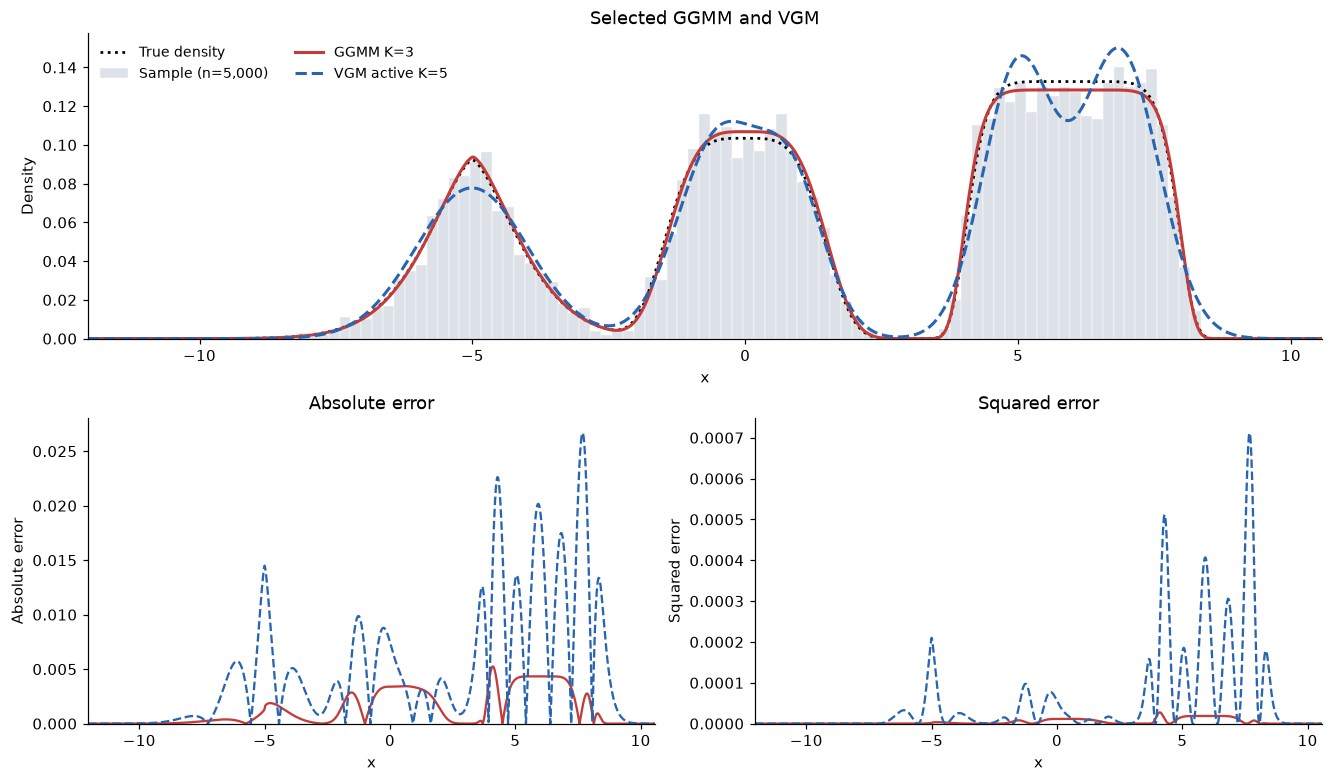

In [4]:
# 실험 1: 선택된 GGMM과 VGM의 밀도·오차 비교
# 현재 result의 추정식·파라미터·IAE·ISE·실측 시간을 표와 그림으로 보여줍니다.
# VGM은 이 셀에서 같은 X로 새로 적합합니다. 다른 실험 셀의 실행은 필요하지 않습니다.
overview_table = report_overview(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
Initial_b는 최종 추정값이 아닌 출발점입니다. 미수렴·중복 생략을 함께 표시합니다.


,K,Chosen_start,quantile_LL,quantile_status,lloyd_LL,lloyd_status
0,1,quantile,-13777.280490,converged,NaN,duplicate / omitted
1,2,lloyd,-12735.934721,converged,-12735.934720,converged
2,3,lloyd,-12666.145715,converged,-12177.312812,converged
3,4,quantile,-12175.128761,converged,-12175.128766,converged
4,5,quantile,-12172.481564,converged,-12174.540095,converged
5,6,quantile,-12171.948443,converged,-12173.137388,converged
6,7,lloyd,-12169.637321,converged,-12168.156474,converged
7,8,quantile,-12165.350955,not converged,-12167.511177,not converged
8,9,quantile,-12163.877190,not converged,-12166.051568,not converged
9,10,lloyd,-12176.808635,not converged,-12172.894512,not converged


,Start,Initial_b,Chosen,Optimize_s,Start_s,Iterations,Nfev
0,quantile,"[2.0, 2.0, 10.28284]",False,0.383500,0.390174,110,123
1,lloyd,"[1.64404, 4.22725, 13.33143]",True,0.158497,0.164073,52,59


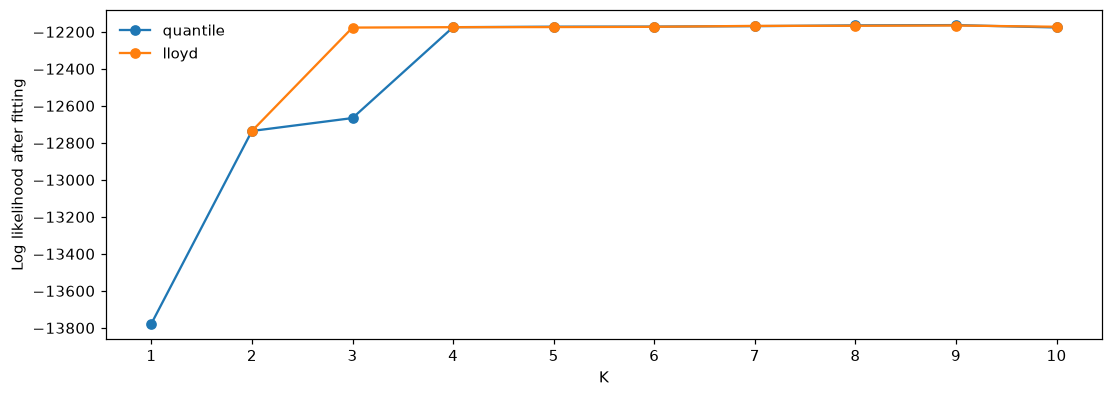

In [5]:
# 실험 2: 각 K에서 어떤 초기화가 채택됐는가?
# Quantile/Lloyd의 우도·수렴·초기 b·시간을 비교합니다. GGMM을 추가 적합하지 않습니다.
initialization_table = report_initialization(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
계산된 유한 후보의 선택: {'LL 최대': 9, 'AIC 최소': 3, 'BIC 최소': 3}
미수렴 후보를 숨기지 않습니다. 현재 선택은 전역 최적해나 참 K 복원을 보장하지 않습니다.
탐색 상한 진단: {'effective_Kmax': 10, 'selected_at_boundary': False, 'last_candidates_BIC_decreasing': False, 'boundary_not_converged': True, 'review_larger_K': False}


,K,log_likelihood,LL_gain,AIC,BIC,selected,converged,max_b,a_floor_hits,seconds
0,1,-13777.280490,NaN,27560.560979,27580.112559,False,True,13.876912,0,0.015078
1,2,-12735.934720,1041.345770,25485.869439,25531.489792,False,True,8.841810,0,0.166713
2,3,-12177.312812,558.621908,24376.625623,24448.314748,True,True,8.842612,0,0.556021
3,4,-12175.128761,2.184051,24380.257522,24478.015420,False,True,5.282206,0,1.135473
4,5,-12172.481564,2.647197,24382.963127,24506.789798,False,True,4176693.654474,0,5.771540
5,6,-12171.948443,0.533121,24389.896886,24539.792329,False,True,14.364729,0,7.035098
6,7,-12168.156474,3.791969,24390.312947,24566.277164,False,True,6.020295,0,12.575123
7,8,-12165.350955,2.805519,24392.701910,24594.734899,False,False,1579973.234613,0,26.031620
8,9,-12163.877190,1.473765,24397.754379,24625.856141,False,False,4255.268615,0,27.038036
9,10,-12172.894512,-9.017323,24423.789025,24677.959559,False,False,332.199926,0,31.807975


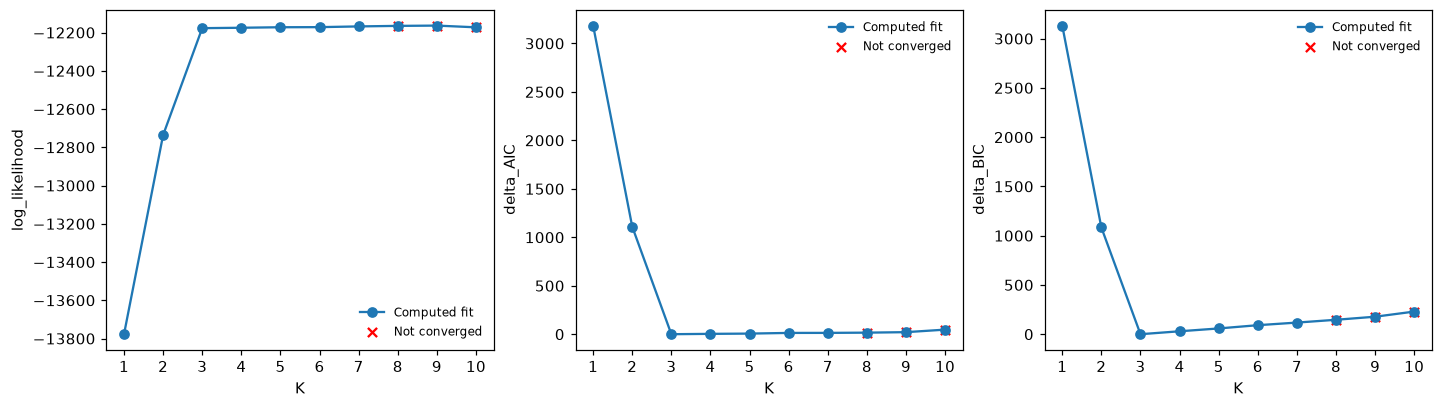

In [6]:
# 실험 3: 우도·AIC·BIC의 K 선택 비교
# 현재 실행의 모든 후보 점수와 미수렴·척도 하한·최대 b를 공개합니다.
selection_table = report_selection(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
전체 GGMM fit() 실측: 112.133106초
Candidate_s는 해당 K의 모든 시작점·초기화·후처리를 포함합니다.
초기화는 K별로 공동 측정합니다. starts.seconds는 초기화 이후 시도 전체입니다.
누적 후보 시간은 현재 실행의 부분합이며, 다른 K_max 독립 실행의 실측값은 아닙니다.


,K,Candidate_s,initialization_seconds,starts_count,converged,Cumulative_candidate_s
0,1,0.015078,0.000623,1,True,0.015078
1,2,0.166713,0.001332,2,True,0.181790
2,3,0.556021,0.001763,2,True,0.737812
3,4,1.135473,0.003143,2,True,1.873284
4,5,5.771540,0.004829,2,True,7.644824
5,6,7.035098,0.004289,2,True,14.679922
6,7,12.575123,0.006866,2,True,27.255045
7,8,26.031620,0.007888,2,False,53.286665
8,9,27.038036,0.009178,2,False,80.324701
9,10,31.807975,0.005082,2,False,112.132676


,K,start,seconds,optimization_seconds,iterations,nfev,converged
0,1,quantile,0.014444,0.012253,11,14,True
1,2,quantile,0.078117,0.073211,25,32,True
2,2,lloyd,0.087250,0.082420,29,35,True
3,3,quantile,0.390174,0.383500,110,123,True
4,3,lloyd,0.164073,0.158497,52,59,True
5,4,quantile,0.670588,0.663517,187,207,True
6,4,lloyd,0.461730,0.455024,128,141,True
7,5,quantile,5.041258,5.032913,995,1293,True
8,5,lloyd,0.725441,0.718033,185,201,True
9,6,quantile,3.753973,3.744094,685,747,True


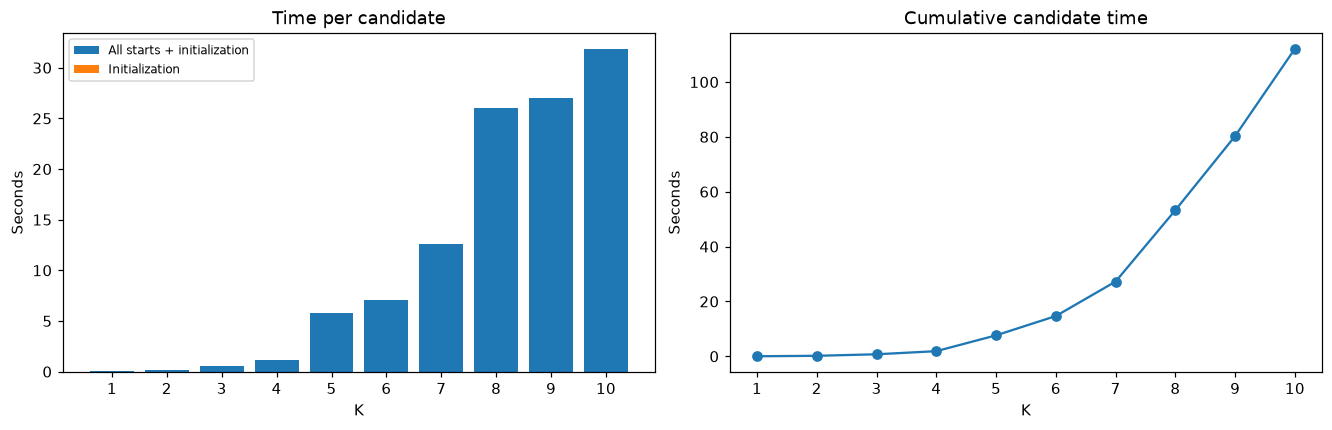

In [7]:
# 실험 4: 적합시간은 어디에서 늘어나는가?
# 전체 fit 시간, K별 시간, 초기화 시간과 시작점별 최적화 시간·반복 수를 보여줍니다.
# 누적 후보 시간과 K_max를 바꾼 독립 재실행의 시간은 서로 다른 측정입니다.
timing_table = report_timing(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
3-kernel 추출 시드: 20260914 | 인덱스: [4522, 3243, 1038]
추출 관측값: [5.818552, 6.024767, -0.722823]
세 모형의 LL은 전체 X에서 평가합니다. 대역폭: Scott. IAE·ISE: 4,000점 사다리꼴 근사.


,Method,Fit_n,Terms,Factor,h,LL_on_all_X,IAE,ISE,Fit_s,LL_s
0,GGMM K=3,5000,3,NaN,NaN,-12177.312812,0.029223,0.000092,112.133106,NaN
1,"Gaussian KDE n=5,000",5000,5000,0.182056,0.815305,-12660.866914,0.264091,0.005210,0.000313,0.750143
2,Gaussian KDE n=3,3,3,0.802742,3.080584,-14662.564453,0.759495,0.036073,0.000205,0.000661


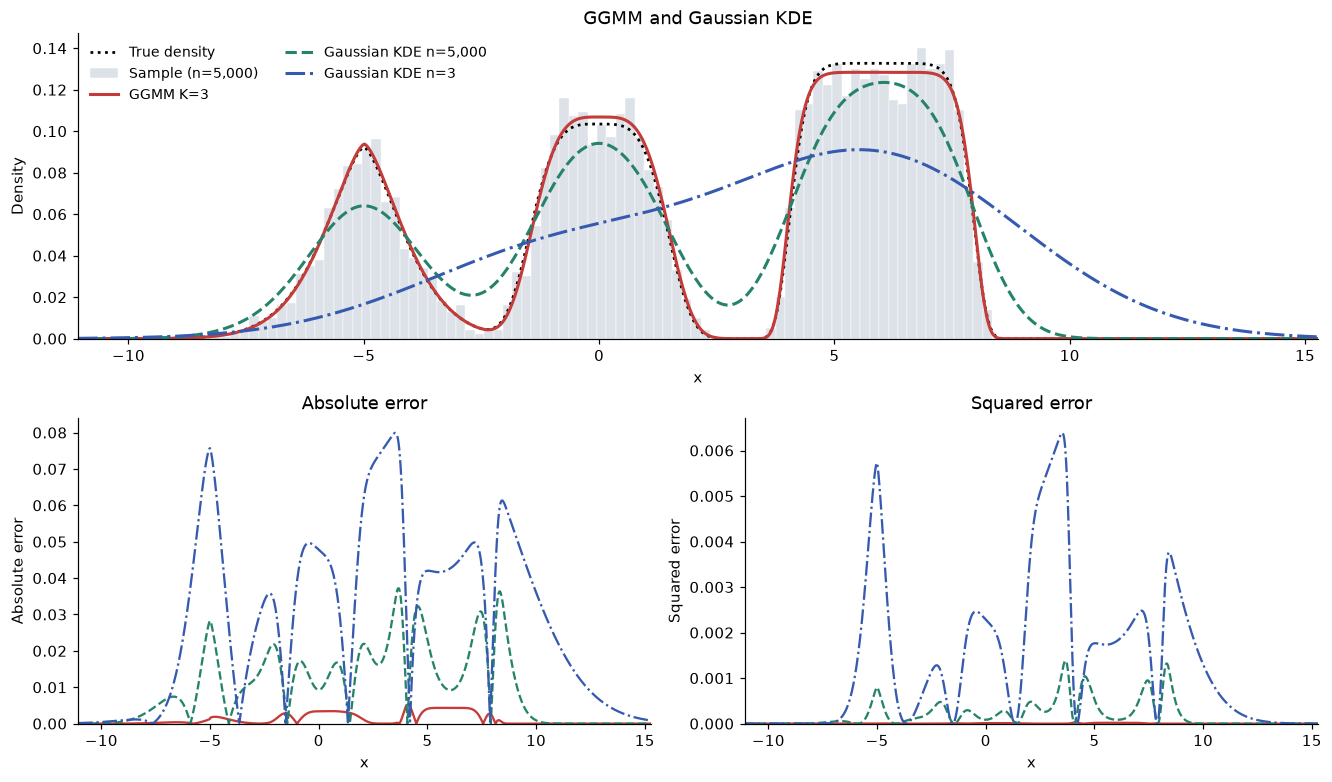

In [8]:
# 실험 5: GGMM과 전체 표본·3개 관측값 KDE 비교
# 같은 X에서 Gaussian KDE를 새로 계산합니다. 표·밀도·참 밀도 오차를 한 셀에서 봅니다.
# 3개 KDE는 표본 중 3개를 뽑은 것이며 전체 X에 3성분을 최적화한 모형은 아닙니다.
kde_table = report_kde(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
VGM의 실제 유효 K와 같은 GGMM 후보를 비교합니다. K=3·5를 강제로 만들지 않습니다.
GGMM은 해당 K의 시간, VGM은 최대 성분 수 전체의 시간으로 비용 범위가 다릅니다.


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,VGM_cap,Parameters
0,GGMM,3,-12177.312812,0.029223,0.000092,0.556021,0.041071,True,True,3,11
1,VGM active,3,-12460.511535,0.213372,0.005165,0.008996,0.044712,True,True,3,8
2,GGMM,5,-12172.481564,0.041329,0.000247,5.771540,0.050609,True,True,10,19
3,VGM active,5,-12270.380570,0.108209,0.001250,0.675710,0.051561,True,True,10,14


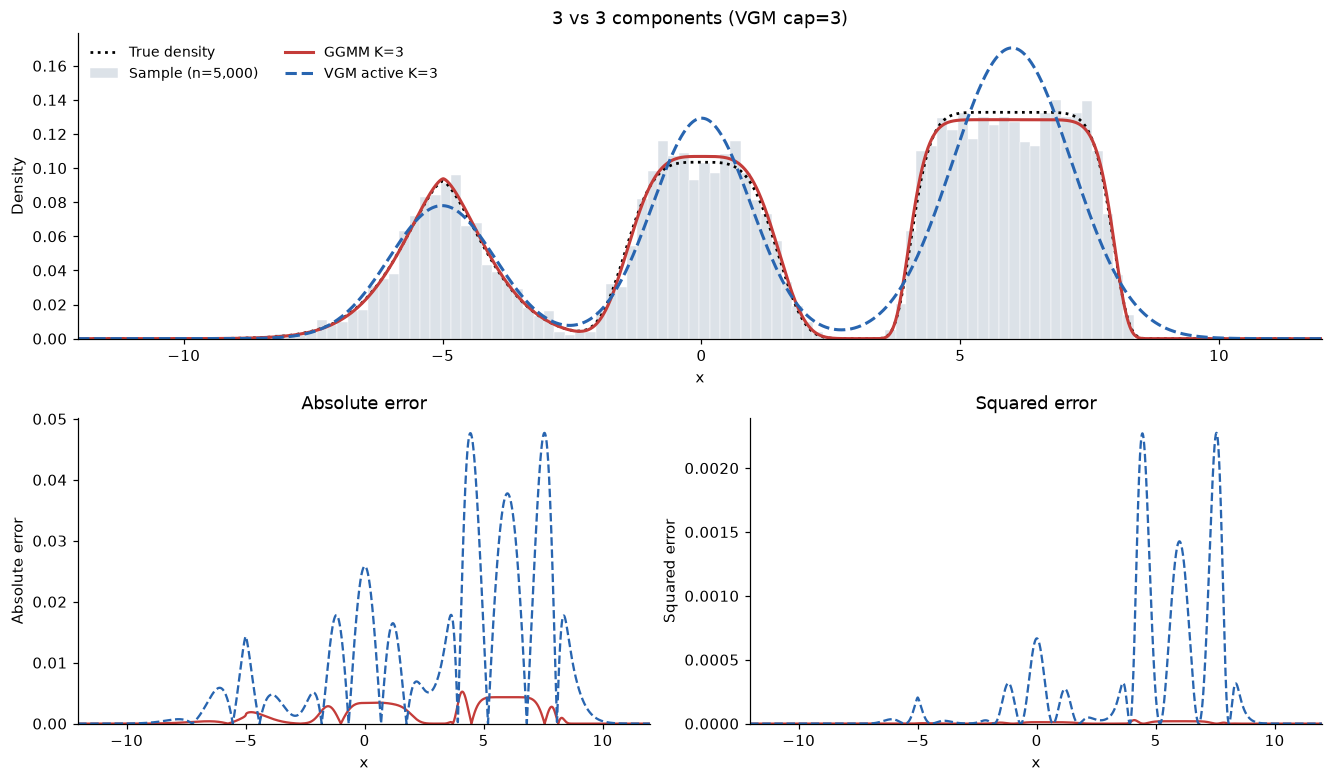

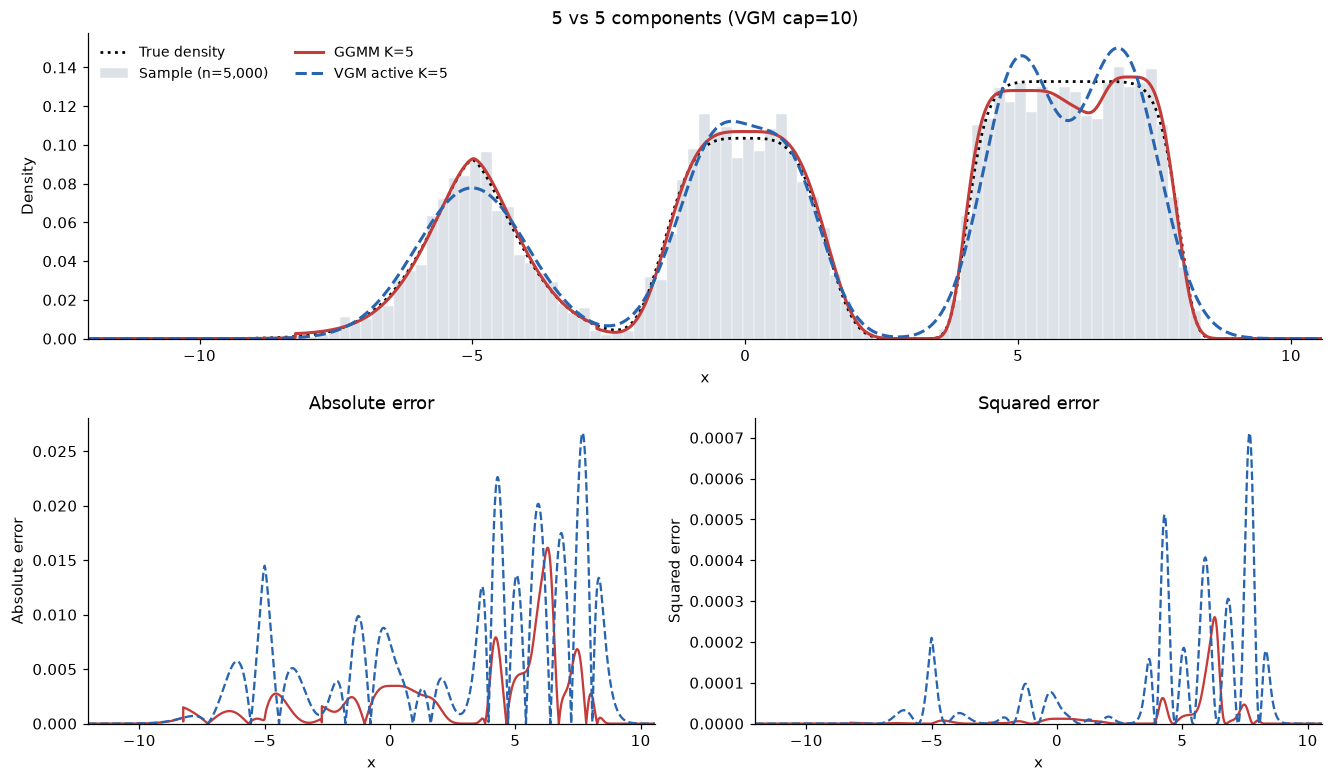

In [9]:
# 실험 6: 실제 성분 수가 같은 GGMM과 VGM 비교
# VGM을 이 셀에서 적합하고 실제 유효 K와 같은 GGMM 후보를 비교합니다.
# 새 표본에서 유효 K가 달라져도 3·5라고 강제 표기하지 않습니다.
same_k_table = report_same_k(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
참 밀도를 아는 경우에만 IAE·ISE를 사후 계산합니다. K 선택에는 사용하지 않습니다.
적분은 넓은 유한 구간의 수치 근사입니다. 실패 후보는 선택·시간 표에서 확인하세요.


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK
0,GGMM K=1,1.000000,-13777.280490,0.636626,0.033414,0.015078,0.040625,True,True
1,GGMM K=2,2.000000,-12735.934720,0.276481,0.009898,0.166713,0.039430,True,True
2,GGMM K=3,3.000000,-12177.312812,0.029223,0.000092,0.556021,0.041785,True,True
3,GGMM K=4,4.000000,-12175.128761,0.039206,0.000246,1.135473,0.043985,True,True
4,GGMM K=5,5.000000,-12172.481564,0.041329,0.000247,5.771540,0.047760,True,True
5,GGMM K=6,6.000000,-12171.948443,0.042227,0.000303,7.035098,0.045115,True,True
6,GGMM K=7,7.000000,-12168.156474,0.050849,0.000438,12.575123,0.053761,True,True
7,GGMM K=8,8.000000,-12165.350955,0.052107,0.000503,26.031620,0.069756,False,True
8,GGMM K=9,9.000000,-12163.877190,0.060950,0.000612,27.038036,0.077823,False,True
9,GGMM K=10,10.000000,-12172.894512,0.074887,0.001242,31.807975,0.092180,False,True


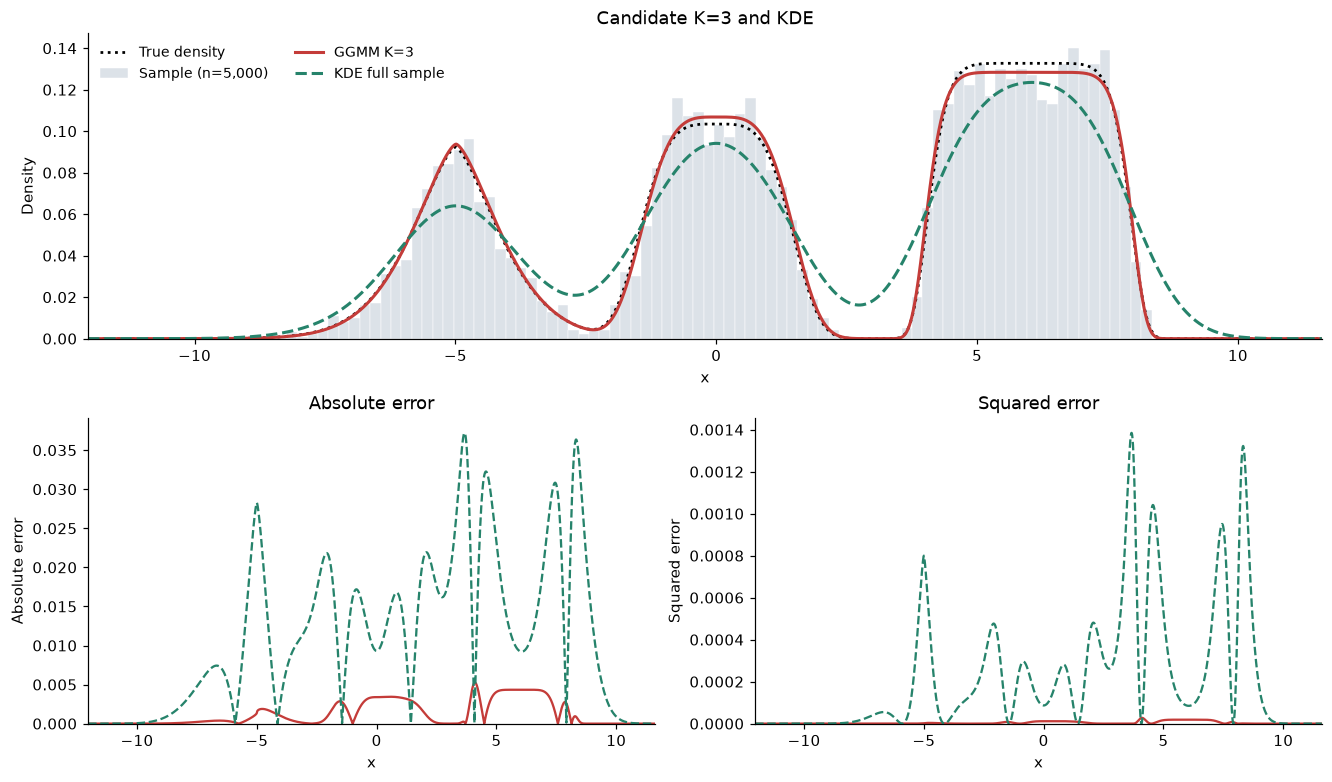

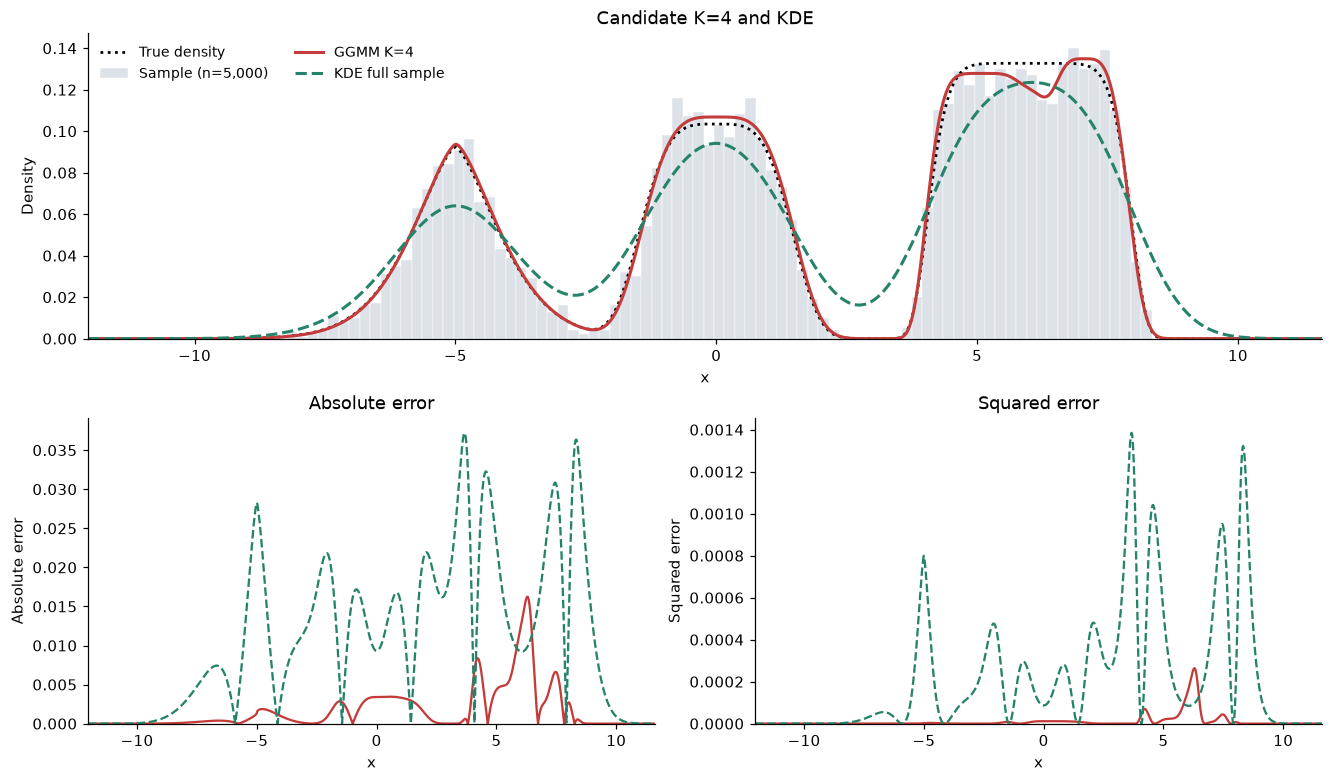

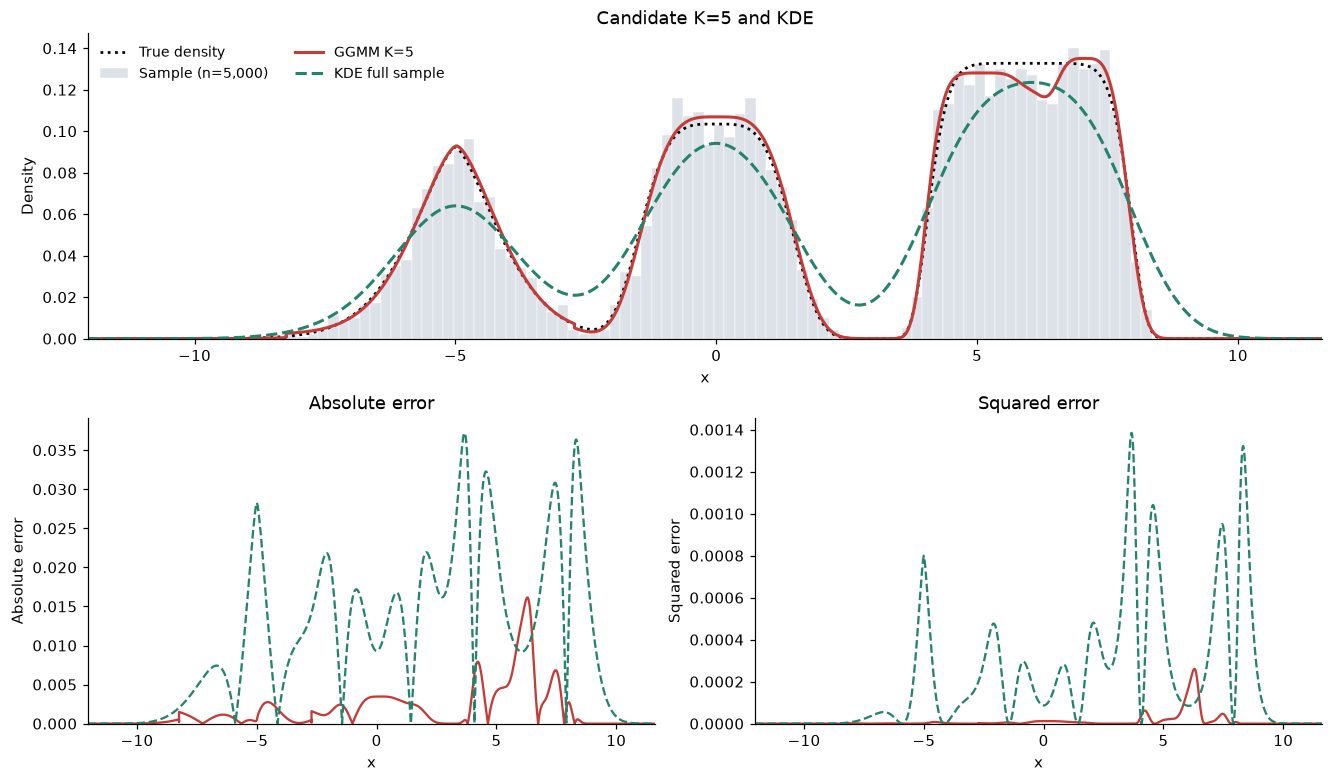

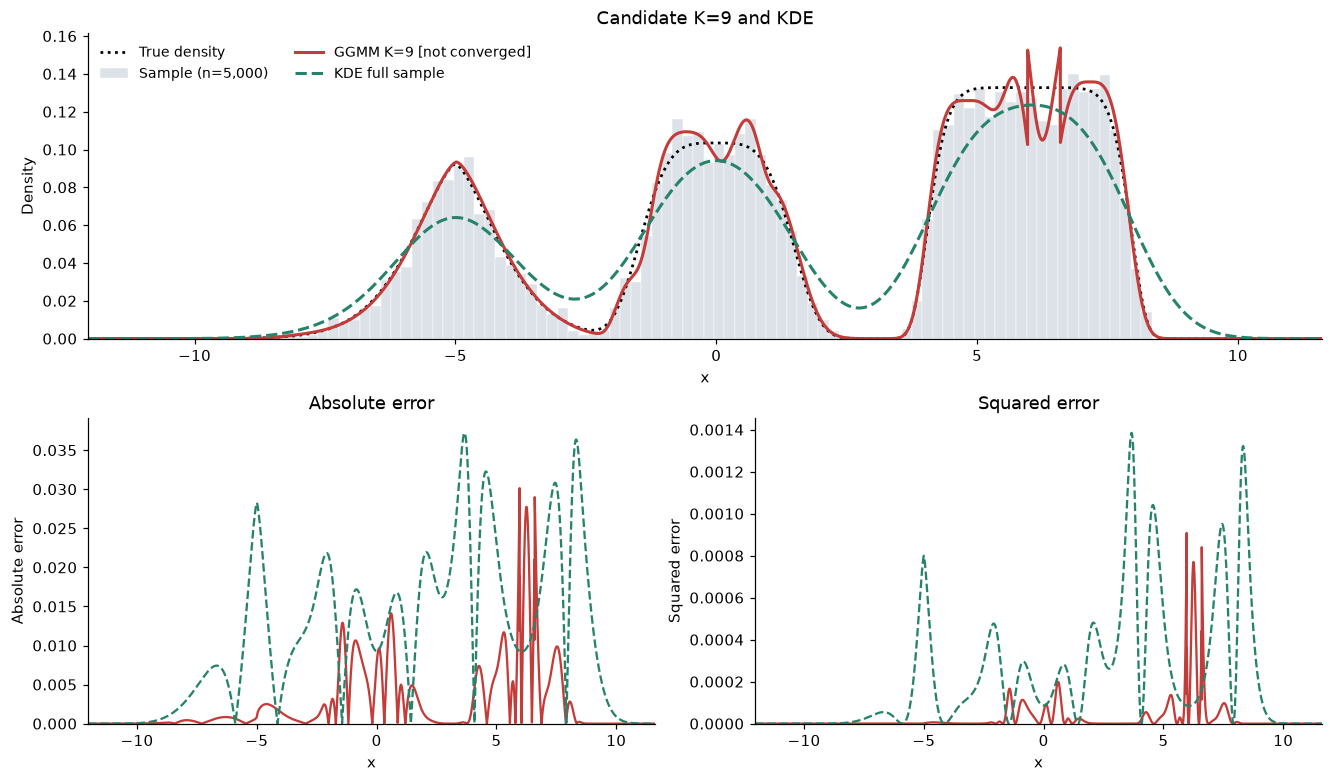

In [10]:
# 실험 7: K별 적합 밀도와 KDE의 참 밀도 오차 비교
# 현재 result의 모든 GGMM 후보를 평가합니다. KDE는 여기서 준비하므로 다른 비교 셀이 필요 없습니다.
# IAE·ISE는 사후 평가이며 모델 선택에 다시 사용하지 않습니다.
all_k_table = report_all_k(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
후보를 K<=2로 제한한 BIC 선택: K=2
전체 후보의 BIC 선택 K=3; 훈련 로그우도 최대 K=9.
같은 실행의 후보를 제한한 진단입니다. K_max=2의 별도 실행시간을 측정한 것은 아닙니다.
참 성분 수 3을 알아서 선택한 것이 아닙니다. 참 밀도는 오차 평가에만 사용합니다.
LL 최대 후보의 파라미터:
큰 K 자체를 실패 원인으로 단정하지 않습니다. 수렴·형상·오차를 함께 확인하세요.


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,BIC,Max_b,Floor_hits,Iterations,Stop_reason
0,GGMM K=2,2,-12735.934720,0.276481,0.009898,0.166713,0.066291,True,True,25531.489792,8.841810,0,29,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
1,GGMM K=3,3,-12177.312812,0.029223,0.000092,0.556021,0.053740,True,True,24448.314748,8.842612,0,52,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
2,GGMM K=9,9,-12163.877190,0.060950,0.000612,27.038036,0.093276,False,True,24625.856141,4255.268615,0,1500,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


,component,weight,mu,a,b,sigma_derived
0,1,0.006198,-5.543867,2.787429,11.583572,1.564634
1,2,0.195322,-4.978317,1.176492,1.540338,0.988658
2,3,0.062015,-0.980547,0.979216,5.861463,0.553059
3,4,0.145797,-0.232558,1.044409,5.871422,0.589840
4,5,0.099026,1.024357,0.711301,2.272298,0.474208
5,6,0.185179,4.790835,0.814535,3.750756,0.477560
6,7,0.074627,5.801414,0.357179,2.133326,0.244726
7,8,0.031625,6.282306,0.313787,4255.268615,0.181140
8,9,0.200211,7.163893,0.819535,3.504887,0.485517


,K,start,log_likelihood,converged,iterations,projected_gradient,max_b,a_floor_hits,message
0,9,quantile,-12163.877190,False,1500,0.002049,4255.268615,0,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
1,9,lloyd,-12166.051568,False,1500,0.000049,6.030006,0,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


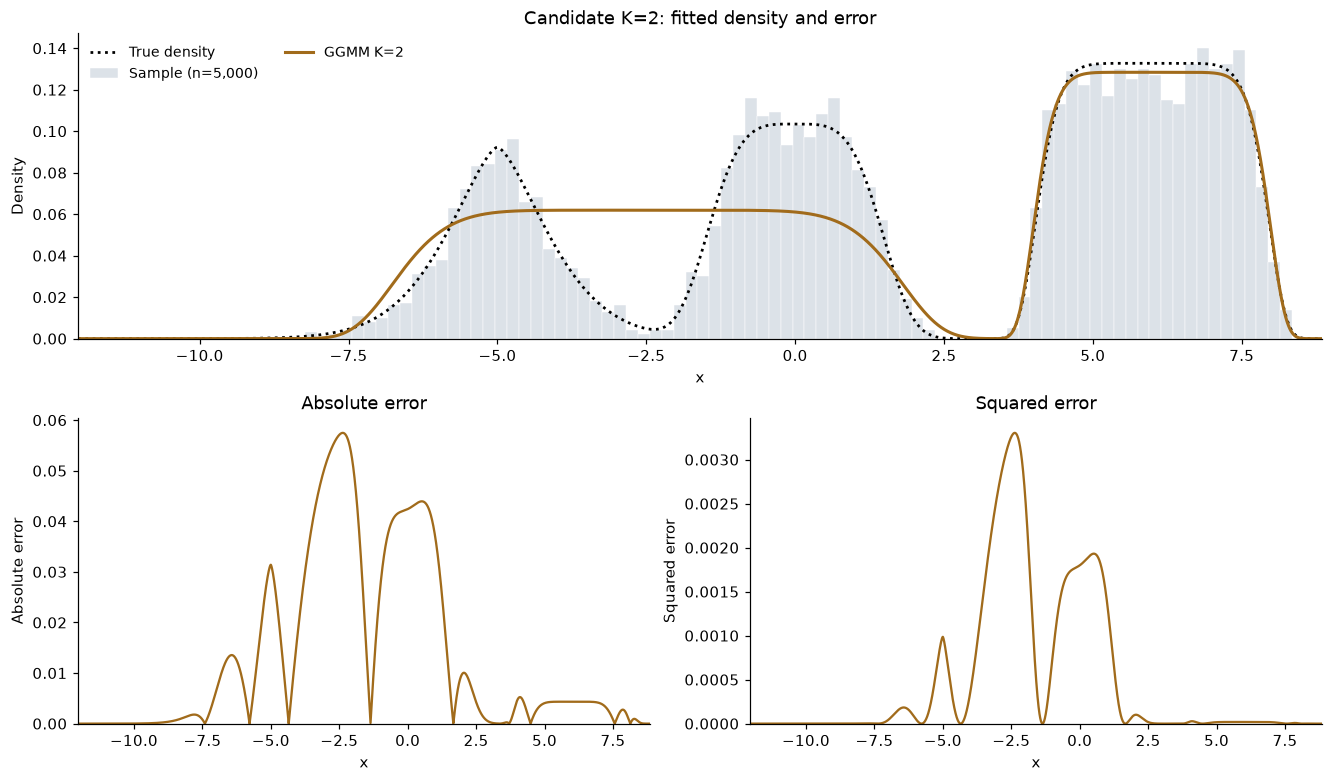

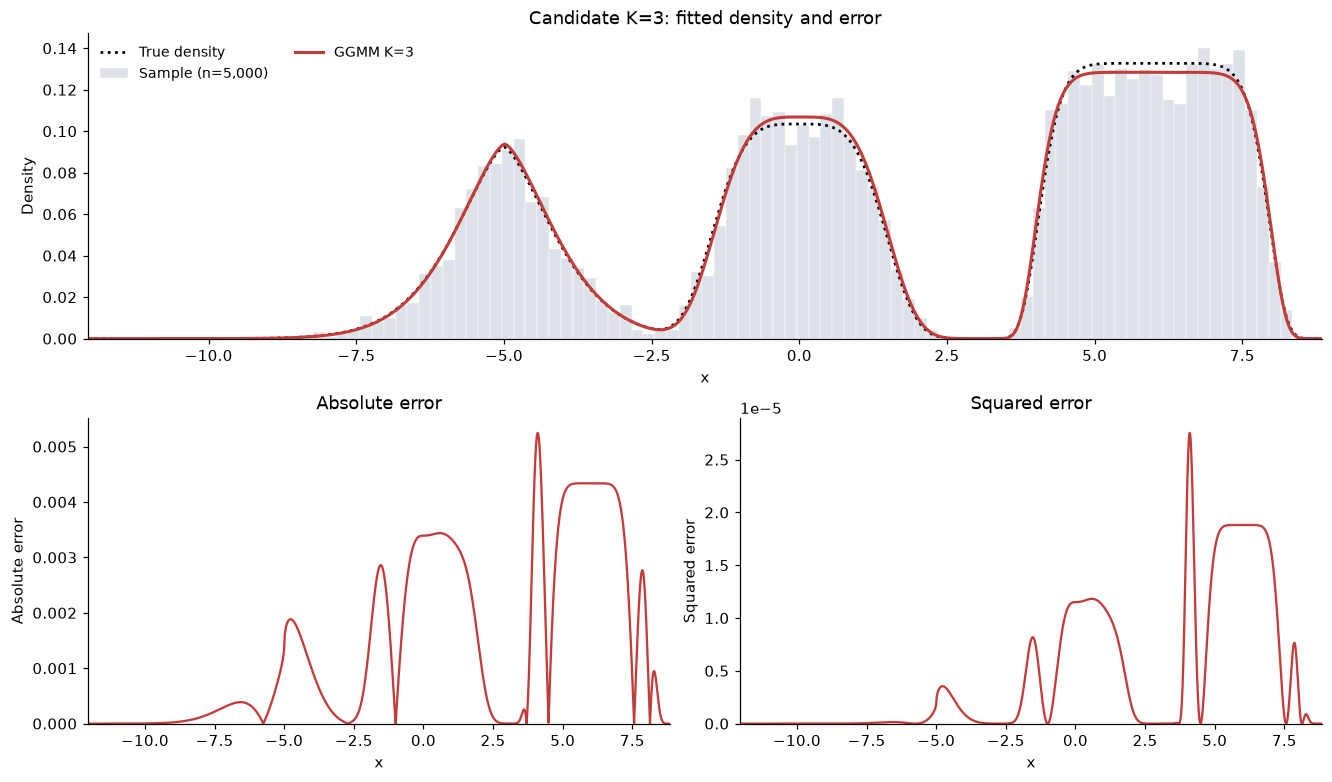

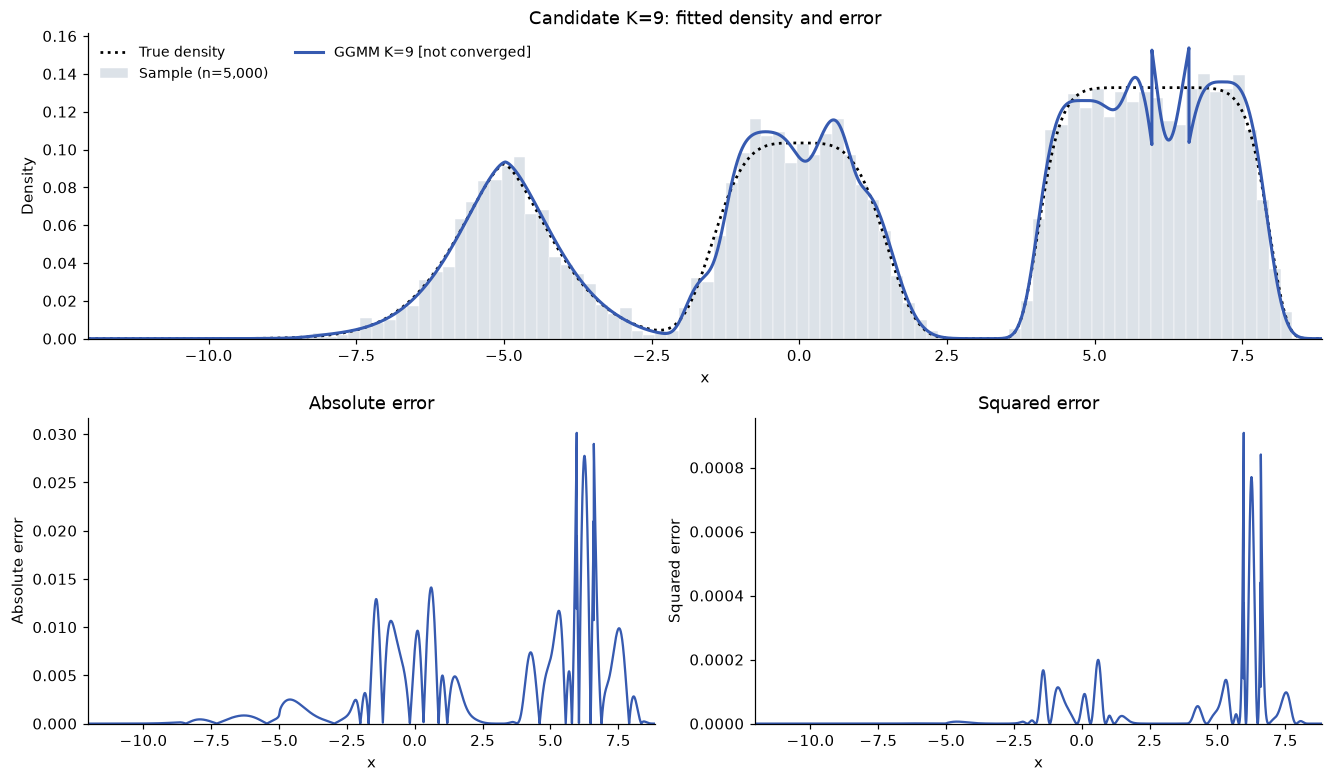

In [11]:
# 실험 8: K_max=2의 후보 제한과 로그우도 최대 K의 실제 적합
# K<=2에서 선택할 수 있는 최선과 전체 BIC 선택, LL 최대 후보를 같은 X로 비교합니다.
# K=9라고 미리 고정하지 않습니다. 현 실행의 LL 최대 후보와 미수렴 여부를 직접 확인합니다.
limits_table = report_restricted_and_high_k(result)


Run: 2026-09-18T02:00:10.837954+00:00 | n=5,000 | K_max=10 | 선택 K=3
하한 없는 모형의 반례: 기존 밀도에 X[0] 중심, b=2, weight=1/n 성분 하나를 추가합니다.
모든 a는 양수입니다. a=0은 올바른 연속 밀도가 아닙니다.
최적화 결과가 아니라, 허용 파라미터 경로에서 계산한 실제 로그우도입니다.
K는 경로 내내 고정됩니다. a→0에서 한 관측점의 밀도가 무한대로 가므로 LL도 발산합니다.
나머지 점은 기존 성분이 맡습니다. 따라서 BIC의 고정된 파라미터 벌점도 이를 막지 못합니다.
현재 fit은 양의 하한을 요구합니다. 작은 양수로 바꾼 실험과 하한 제거는 다릅니다.


,Neg_log10_relative_a,a,LL,LL_gain_vs_base,Log_weighted_peak,K,BIC
0,0,4.477864,-12177.436197,-0.123385,-10.588704,4,24482.630292
1,1,0.447786,-12177.316649,-0.003838,-8.286119,4,24482.391196
2,2,0.044779,-12177.481755,-0.168944,-5.983534,4,24482.721409
3,4,0.000448,-12175.816908,1.495903,-1.378364,4,24479.391714
4,8,0.000000,-12168.149734,9.163078,7.831977,4,24464.057365
5,16,0.000000,-12149.729091,27.583720,26.252657,4,24427.216081
6,32,0.000000,-12112.887730,64.425082,63.094019,4,24353.533358
7,64,0.000000,-12039.205007,138.107805,136.776742,4,24206.167912
8,128,0.000000,-11891.839561,285.473251,284.142188,4,23911.437020
9,256,0.000000,-11597.108669,580.204143,578.873080,4,23321.975236


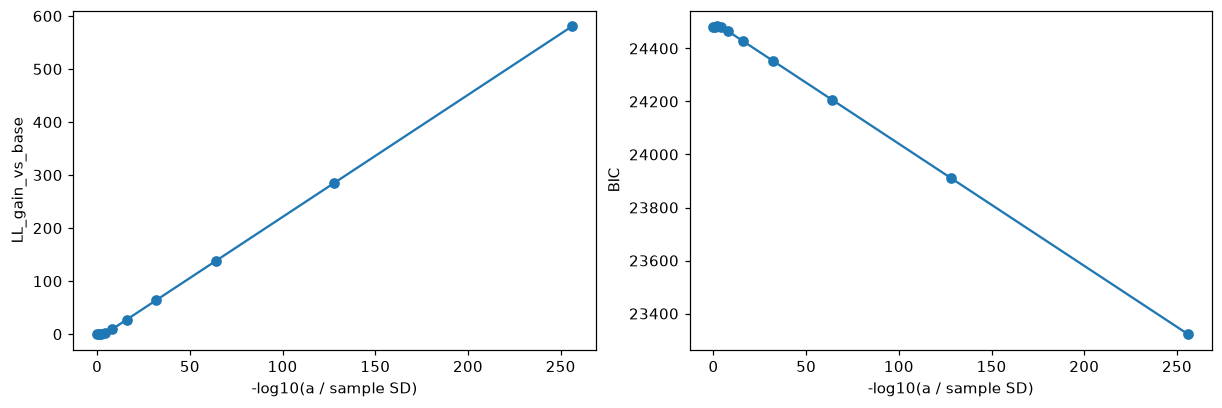

In [12]:
# 실험 9: 척도 하한이 없을 때 우도가 발산하는 반례
# 적합값을 조작해 성능을 주장하는 실험이 아닙니다. 제약 없는 모형의 문제를 보이는 진단입니다.
# 관측점 한 곳의 성분만 계속 좁힐 때 LL·BIC가 어떻게 바뀌는지 계산합니다.
collapse_table = report_scale_collapse(result)


In [13]:
# 선택 실험 10: K_max=10과 20을 각각 처음부터 적합
# RUN_KMAX_COMPARISON=True로 바꾸면 같은 X를 두 번 독립 적합해 시간을 비교합니다.
# 적합비용이 드는 별도 연구 실행입니다. 기본 result는 덮어쓰지 않습니다.
RUN_KMAX_COMPARISON = False
KMAX_VALUES = [10, 20]
if RUN_KMAX_COMPARISON:
    kmax_results, kmax_table = compare_kmax(result, KMAX_VALUES)
    runs.update({run['run_id']: run for run in kmax_results})
else:
    print('미실행: K_max 독립 비교가 필요하면 RUN_KMAX_COMPARISON=True로 설정하세요.')


미실행: K_max 독립 비교가 필요하면 RUN_KMAX_COMPARISON=True로 설정하세요.


In [14]:
# 선택 실험 11: 척도 하한을 바꾸어 실제 재적합
# RUN_SCALE_SENSITIVITY=True일 때만 실행합니다. 이전 표본의 민감도 결과를 재사용하지 않습니다.
# 각 조건의 새 result는 sensitivity_results와 runs에 남고 기본 result는 유지됩니다.
RUN_SCALE_SENSITIVITY = False
SCALE_FLOORS = [1e-4, 1e-3, 1e-2]
if RUN_SCALE_SENSITIVITY:
    sensitivity_results, sensitivity_table = compare_scale_floors(result, SCALE_FLOORS)
    runs.update({run['run_id']: run for run in sensitivity_results})
else:
    print('미실행: 하한 비교가 필요하면 RUN_SCALE_SENSITIVITY=True로 설정하세요.')


미실행: 하한 비교가 필요하면 RUN_SCALE_SENSITIVITY=True로 설정하세요.
